# Reproducing Andersen+26 Figures

Here we provide code for reproducing Figures 3-16 in Andersen+26 (if you want the `pptx` files used to create Figure 1 + 2, contact the corresponding author, Bridget C. Andersen). 

If you wish to run through this notebook, you will need to download the digest for each simulation (see Table 11 in Andersen+26 and Step 5 in `Simulate_Run_PATH.ipynb`) at this Google Drive link: [link](https://drive.google.com/drive/folders/1Rv6koYfKJ7yQ5xYV666gIaMQ2wX0A6Tg?usp=drive_link). The files are descriptively named: 

`digest_<loc>_<intrinsic_offset_distribution>_<offset_prior>_<magnitude_prior>_<unseen_prior>_<catalog>.parquet`

For example, `digest_a25b2pa12_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL.parquet` is a simulation with the "CK" localization (see the top of Figure 6 of Andersen+26), an exponential intrinsic offset distribution, an exponential PATH offset prior, an inverse magnitude prior, a unseen prior of $P(U) = 0.15$, run with the `DECALs` catalog (the first entry in Table 11).

For the estimation of $P(U)$ (Figure 7), you will also need to download both of the pre-queried PATH catalogs at this Google Drive link: [link](https://drive.google.com/drive/folders/1PKqh8tnDLbtqIuGeoPFEEh60ovs8Zjw8?usp=drive_link)
- `Pan-STARRS`: download `catalog_dudxmmlss_hecate_Pan-STARRS.parquet`
- `DECaLs`: download `catalog_dudxmmlss_hecate_DECaL.parquet`

See Section 3.3 of Andersen+24 and Step 4 of `Simulate_Run_PATH.ipynb` for a description of these catalogs. Fair warning: these files are very large, 900 MB and 6.1 GB for `Pan-STARRS` and `DECaLs`, respectively. 


Download each of these files and save them in the directory defined by the `FRB_APATH` environmental variable.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
params = {'axes.labelsize':20,
         'axes.titlesize':20,
         'xtick.labelsize':20,
         'ytick.labelsize':20}
pylab.rcParams.update(params)
from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
rc('text', usetex=False)
import matplotlib

import os
import pandas as pd
import numpy as np
from importlib.resources import files
from pathlib import Path
import random
import scipy

In [2]:
from frb.dm import prob_dmz
import scipy.stats as stats
from scipy.interpolate import CloughTocher2DInterpolator
from astropy.cosmology.realizations import Planck18 as cosmo
from astropy import units as u
from astropath.simulations import load_galaxy_catalog
from astropath.simulations import utils as sim_utils

In [3]:
import astropy.units as u
from astropy.coordinates import SkyCoord

In [4]:
# Set the directory where simulation data and catalogs are downloaded
os.environ['FRB_APATH'] = '/Users/bandersen/Documents/CHIME/notebooks/path_simulations/catalogs/'

## Figure 3

In [117]:
# Load in simulations digest
fn = os.path.join(os.getenv('FRB_APATH'), 'final_sims', 'digest_a25b2pa12_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_final.parquet')
df = pd.read_parquet(fn)

In [118]:
# Load DMs from CHIME/FRB Catalog 1 with S/N > 12
fn = files('astropath.data') / 'frb_surveys' / 'chimefrbcat1.csv'
df_dr1 = pd.read_csv(fn)
chime_dms_eg = np.nanmean([df_dr1['dm_exc_ne2001'].values,df_dr1['dm_exc_ymw16'].values], axis=0)
chime_snrs = df_dr1['bonsai_snr']
threshold = 12.
chime_observed_dms_eg = chime_dms_eg[chime_snrs > threshold]
print(f"Observed CHIME/FRB DMs: N={len(chime_observed_dms_eg)}, median={np.median(chime_observed_dms_eg):.0f}" + r"$\rm pc cm^{-3}$")

Observed CHIME/FRB DMs: N=402, median=411$\rm pc cm^{-3}$


In [119]:
# Calculate KDE of Catalog 1 DMs
DMex = df['dmex_host'].values
kernel = stats.gaussian_kde(DMex)
dms = np.linspace(0., 3000, 500)
DMex_kde = kernel(dms)

# Grab simulated redshifts
zs = df['z_host'].values

In [120]:
# Load the survey-specific P(z,DM) grid
# First load grid to get z and DM arrays (they're the same for all)
grid_data = prob_dmz.grab_repo_grid('CHIME_pzdm.npz')
z = grid_data['z']
DM_EG = grid_data['DM']
grid = grid_data['pzdm']
pzDM = grid.flatten()

DM, Z = np.meshgrid(DM_EG, z)  # 2D grid for interpolation
interp = CloughTocher2DInterpolator(list(zip(Z.ravel(), DM.ravel())), grid.ravel(), fill_value=np.nan)
# Make new regular grid of z, dm coordinates
z_new_list = np.linspace(0, 2.5, 500)
dm_new_list = np.linspace(0, 4000, 500)
z_new, dm_new = np.meshgrid(z_new_list, dm_new_list)
Pz_dm_interp = interp(z_new, dm_new)
Pz_dm_interp[Pz_dm_interp < 0.] = 0.

Loading P(DM,z) grid from /Users/bandersen/miniforge3/envs/frbs2/lib/python3.11/site-packages/frb/data/DM/CHIME_pzdm.npz


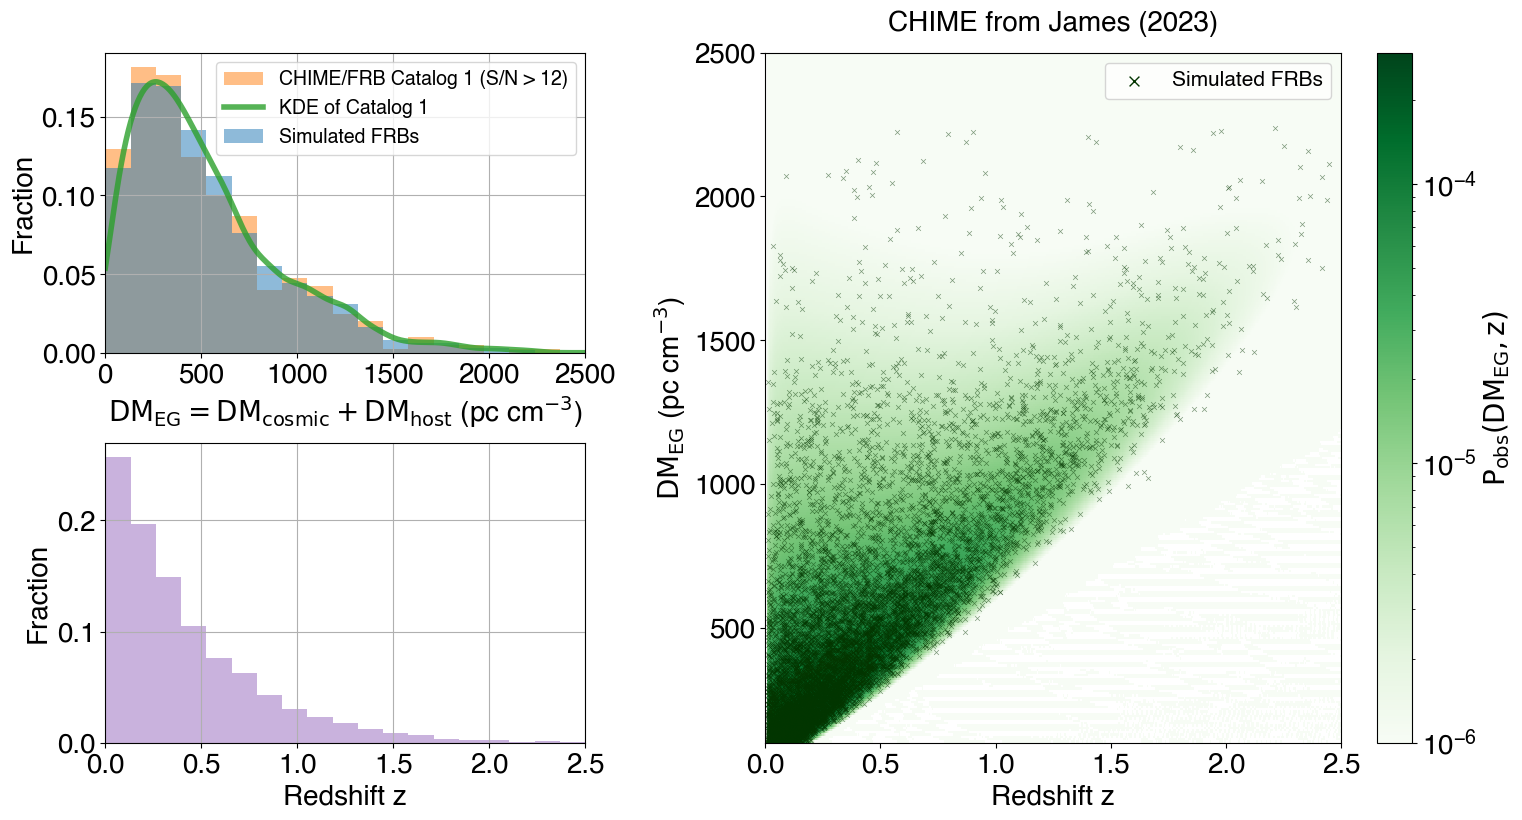

In [121]:
fig = plt.figure(figsize=(12, 6))
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

# (left, bottom, width, height)
height = 1/2.
sep_h = 0.15
width = 0.4
sep_w = 0.15
ax_z = (0., 0., width, height)
ax_dmeg = (0., (height+sep_h), width, height)
ax_pzdm = (width+sep_w, 0., 0.6, height*2+sep_h)

ax = plt.axes(ax_pzdm)
my_cmap = matplotlib.colormaps['Greens'] # copy the default cmap, cubehelix
# my_cmap.set_bad((0,0,0))
pc = ax.pcolormesh(
    z_new, dm_new, Pz_dm_interp, cmap=my_cmap, 
    norm=matplotlib.colors.LogNorm(vmin=1e-6), # vmin=1e-6, vmax=2e-4
    rasterized=True,
)
plt.colorbar(pc, label=r'$\rm P_{obs}(DM_{EG},z)$')
# plt.scatter(z_samp, DM_EG_samp, color='xkcd:lightish blue', alpha=.5, s=12, linewidth=0.5, edgecolor='xkcd:dark blue', rasterized=True)
plt.scatter(zs, DMex, marker='x', color='xkcd:dark green', alpha=.5, s=12, linewidth=0.5, rasterized=True, label='Simulated FRBs')
plt.xlim([0, 2.5])
plt.ylim([100, 2500])
plt.xlabel('Redshift z')
plt.ylabel(r'$\rm DM_{EG}$ (pc cm$^{-3}$)')#' = DM_{cosmic} + DM_{host}$ (pc cm$^{-3}$)')
plt.title(r'CHIME from James (2023)', fontsize=20, y=1.02) #  $\rm P_{obs}(z|DM_{EG})$
leg = plt.legend(fontsize=15)
for lh in leg.legend_handles:
    lh.set_alpha(1)
    lh.set_sizes([50])
    lh.set_linewidth([1])
    
ax = plt.axes(ax_dmeg)
bins = np.linspace(0,2500,20)
density = False
weights = np.ones_like(chime_observed_dms_eg) / float(len(chime_observed_dms_eg))
counts, bin_edges, _ = plt.hist(chime_observed_dms_eg, bins=bins, color=cycle[1], weights=weights, density=density, alpha=0.5, label='CHIME/FRB Catalog 1 (S/N > 12)')
bin_width = np.diff(bin_edges)[0]  # array of bin widths
N = len(DMex)
norm = N * bin_width  # one per bin
plt.plot(dms, DMex_kde * norm / float(len(DMex)), color=cycle[2], alpha=0.8, lw=4, label='KDE of Catalog 1')#  / np.nanmax(DMex_kde)*np.nanmax(hist[0])
weights = np.ones_like(DMex) / float(len(DMex))
hist = plt.hist(DMex, bins=bins, color=cycle[0], weights=weights, density=density, alpha=0.5, label='Simulated FRBs')
plt.xlim([0,2500])
plt.ylabel('Fraction')
plt.grid(zorder=1)
plt.legend(fontsize=14)
# _ = plt.yticks(np.arange(0, 1000+1, 500))
plt.xlabel(r'$\rm DM_{EG} = DM_{cosmic} + DM_{host}$ (pc cm$^{-3}$)')

ax = plt.axes(ax_z)
bins = np.linspace(0,2.5,20)
weights = np.ones_like(zs) / float(len(zs))
hist = plt.hist(zs, bins=bins, weights=weights, density=density, color=cycle[4], alpha=0.5)
plt.ylabel('Fraction')
plt.xlim([0,2.5])
plt.grid(zorder=1)
plt.xlabel(r'Redshift z')

plot_fn = os.path.join(os.getenv('FRB_APATH'), 'paper_figures', 'frb_props_redo_norm.pdf')
plt.savefig(plot_fn, dpi=200, format="pdf", bbox_inches="tight")

## Figure 4

In [122]:
# Load in simulations digest
fn = os.path.join(os.getenv('FRB_APATH'), 'final_sims', 'digest_a25b2pa12_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_final.parquet')
df = pd.read_parquet(fn)

In [123]:
# Load in the combined host catalog
combined_catalog_fn = os.path.join(os.getenv('FRB_APATH'), 'combined_HSC_PS1_HECATE_galaxies.parquet')
combined_catalog = pd.read_parquet(combined_catalog_fn)

In [124]:
# Get absolute magnitudes of 46 known FRB hosts
fn = files('astropath.data') / 'frb_surveys' / 'Lz_host_data.csv' # From Alexa Gordon, complete up to Shannon+24
df_known = pd.read_csv(fn)
# Scale mrs with z's to find distribution of Mrs
mrs = np.array(df_known['r-band'])
zs_mrs = np.array(df_known['redshift'])
# Get luminosity distance
ds = cosmo.luminosity_distance(zs_mrs).to(u.parsec).value
# Calculate absolute magnitudes
Mrs = mrs - 5. * np.log10(ds) + 5

# Calculate KDE of absolute magnitudes
kernel = stats.gaussian_kde(Mrs)
mags = np.linspace(-25., -15., 500)
Mr_kde = kernel(mags)

# Get simulated absolute magnitudes
Mrs_sim = df['frb_Mr']

# Get simulated apparent magnitudes
host_m_r = df['frb_mr']

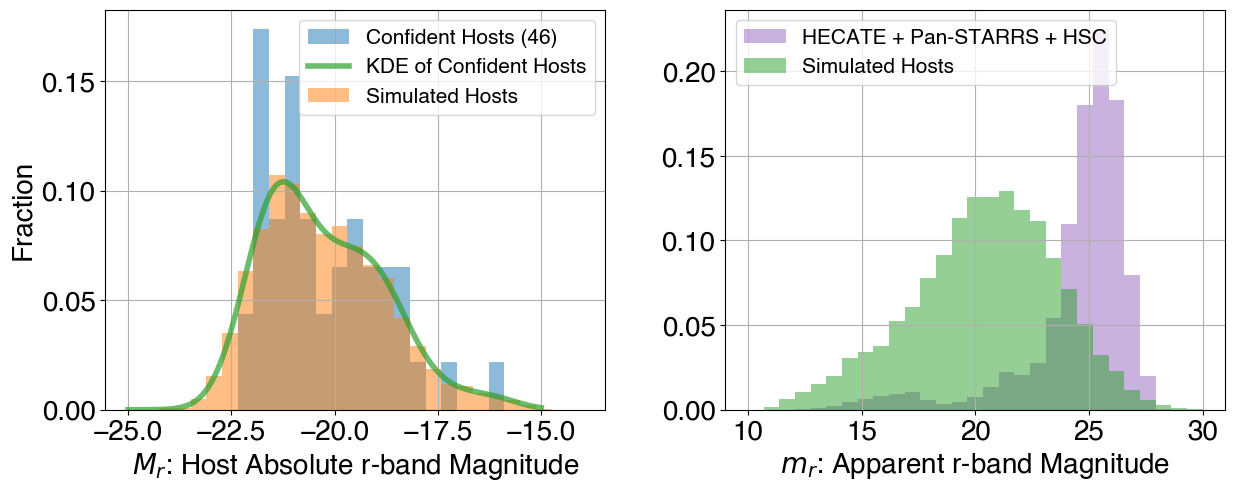

In [126]:
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

# (left, bottom, width, height)
width = 0.5
sep_w = 0.12
Mr_ax = (0., 0., width, 1.)
mr_ax = (width+sep_w, 0., width, 1.)

fig = plt.figure(figsize=(10,4))

ax = plt.axes(Mr_ax)
bins = np.linspace(-25, -14, 30)
weights = np.ones_like(Mrs) / float(len(Mrs))
counts, bin_edges, _ = plt.hist(Mrs, bins=bins, color=cycle[0], lw=4, alpha=0.5, weights=weights, density=False, label=f"Confident Hosts ({len(Mrs)})")
bin_width = np.diff(bin_edges)[0]  # array of bin widths
N = len(Mrs)
norm = N * bin_width  # one per bin
plt.plot(mags, Mr_kde * norm / float(len(Mrs)), color=cycle[2], lw=4, label='KDE of Confident Hosts', alpha=0.7)
weights = np.ones_like(Mrs_sim) / float(len(Mrs_sim))
hist = plt.hist(Mrs_sim, bins=bins, color=cycle[1], weights=weights, density=False, alpha=0.5, label='Simulated Hosts')
plt.xlabel('$M_r$: Host Absolute r-band Magnitude')
plt.ylabel('Fraction')
plt.legend(fontsize=15)
plt.grid(zorder=1)

ax = plt.axes(mr_ax)
bins = np.linspace(10, 30, 30)
inds = np.random.randint(low=0, high=len(combined_catalog), size=500000)
weights = np.ones_like(combined_catalog.iloc[inds]['mag']) / float(len(combined_catalog.iloc[inds]['mag']))
hist, bins, _ = plt.hist(combined_catalog.iloc[inds]['mag'], bins=bins, color=cycle[4], lw=4, alpha=0.5, density=False, weights=weights, label=f"HECATE + Pan-STARRS + HSC")
weights = np.ones_like(host_m_r) / float(len(host_m_r))
hist, bins, _ = plt.hist(host_m_r, bins=bins, color=cycle[2], lw=4, alpha=0.5, density=True, weights=weights, label=f"Simulated Hosts")
plt.grid(zorder=1)
plt.xlabel('$m_r$: Apparent r-band Magnitude')
plt.legend(fontsize=15, loc='upper left')

plot_fn = os.path.join(os.getenv('FRB_APATH'), 'paper_figures', 'Mr_distribution_redo_norm.pdf')
plt.savefig(plot_fn, dpi=200, format="pdf", bbox_inches="tight")

## Figure 5

In [127]:
# Load in simulations digest
fn = os.path.join(os.getenv('FRB_APATH'), 'final_sims', 'digest_a25b2pa12_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_final.parquet')
df = pd.read_parquet(fn)

In [128]:
# Load in the combined host catalog
combined_catalog_fn = os.path.join(os.getenv('FRB_APATH'), 'combined_HSC_DECaLs_HECATE_galaxies_hecatecut.parquet')
combined_catalog = pd.read_parquet(combined_catalog_fn)

In [129]:
# Load in the pre-queried galaxy catalog
fn = 'catalog_dudxmmlss_hecate_DECaL.parquet'
path_catalog_fn = Path(os.getenv('FRB_APATH')) / fn
if path_catalog_fn.exists():
    path_catalog = load_galaxy_catalog(catalog_fn=fn)
else:
    raise FileNotFoundError(f"The file {fn} does not exist")

Loading real galaxy catalog from:
  /Users/bandersen/Documents/CHIME/notebooks/path_simulations/catalogs/catalog_dudxmmlss_hecate_DECaL.parquet


In [130]:
# Vectorized catalog identification (works for astropy Table or pandas DataFrame)
conditions = [
    ~np.isnan(combined_catalog['DECaL_ID'].astype(float)),
    ~np.isnan(combined_catalog['HSC_ID'].astype(float)),
    combined_catalog['SDSS_PHOTID'] != None,
]
choices = ['DECaL', 'HSC', 'HECATE']

orig_catalog = np.select(conditions, choices, default='')
orig_ras = np.array(combined_catalog['ra'])
orig_decs  = np.array(combined_catalog['dec'])

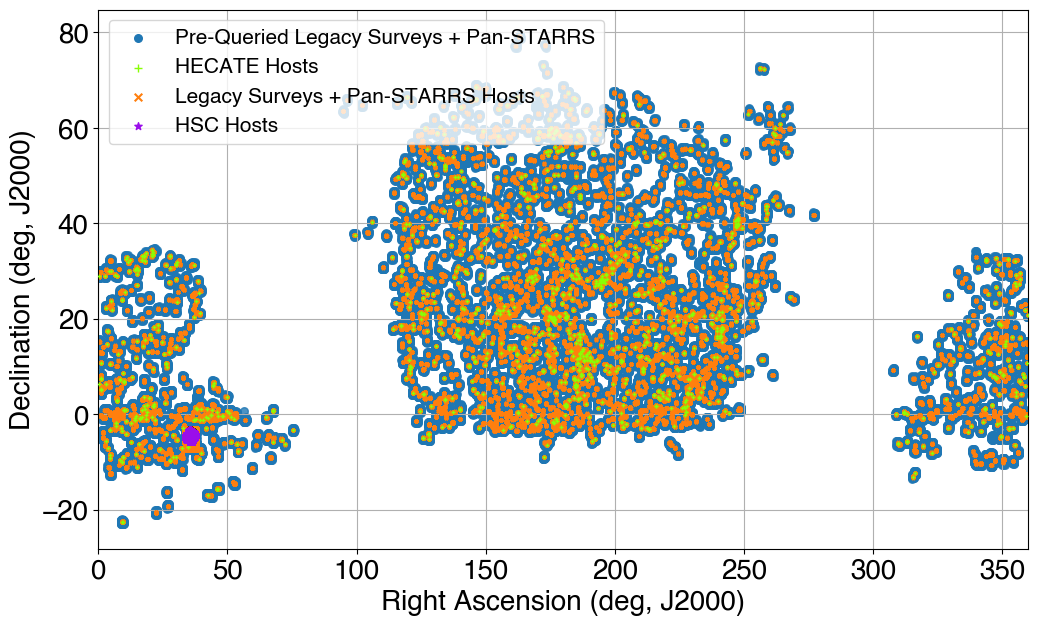

In [131]:
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig = plt.figure(figsize=(12,7))

plot_cat = path_catalog[::1000]
plt.scatter(plot_cat['ra'], plot_cat['dec'], color=cycle[0], s=30, alpha=0.8, label='Pre-Queried Legacy Surveys + Pan-STARRS', rasterized=True, zorder=1)
plt.scatter(orig_ras[orig_catalog == 'HECATE'], orig_decs[orig_catalog == 'HECATE'], color='xkcd:lime green', s=10, linewidths=1, alpha=1, marker='+', label='HECATE Hosts', rasterized=True, zorder=3)
plt.scatter(orig_ras[orig_catalog == 'DECaL'], orig_decs[orig_catalog == 'DECaL'], color=cycle[1], s=5, alpha=1, marker='x', label='Legacy Surveys + Pan-STARRS Hosts', rasterized=True, zorder=2)
plt.scatter(orig_ras[orig_catalog == 'HSC'], orig_decs[orig_catalog == 'HSC'], color='xkcd:violet', s=10, alpha=1, linewidths=1, marker='*', label='HSC Hosts', rasterized=True, zorder=4)
plt.xlabel('Right Ascension (deg, J2000)') # amethyst
plt.ylabel('Declination (deg, J2000)')
lgnd = plt.legend(loc='upper left', fontsize=15)
plt.xlim([0,360])
plt.grid()
# Set a visible legend marker
for l in lgnd.legend_handles:
    l._sizes = [30]
    l._alpha = [1.]

plot_fn = os.path.join(os.getenv('FRB_APATH'), 'paper_figures', 'selected_hosts_by_catalog_recolor.pdf')
plt.savefig(plot_fn, dpi=200, format="pdf", bbox_inches="tight")

## Figure 6

In [5]:
# Create localization PDFs
def gauss(x, A, x0, sigma):
    return A*np.exp(-(x - x0) ** 2 / (2 * sigma ** 2))

def rot(theta):
    theta = np.deg2rad(theta)
    return np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta), np.cos(theta)]
    ])

# Set coordinate axes
xlim = 60.
ylim = 60.
n = 3000
xs = np.linspace(-xlim, xlim, n)
ys = np.linspace(-ylim, ylim, n)
xv, yv = np.meshgrid(xs, ys)

# Find the Dec of a source at the middle of the CHIME beam
CHIMELATITUDE = 49.3207092194
ra = 0.
dec = CHIMELATITUDE

# Calculate example baseline geometry
baseline_chime_kko = (0.8648973412830646, -0.09890619626160913) # delta RA, delta DEC
delta_ra = baseline_chime_kko[0] * np.cos(np.deg2rad(dec))
delta_dec = baseline_chime_kko[1]
theta_chime_kko = np.arctan(delta_dec / delta_ra)*180./np.pi

baseline_chime_gbo = (-0.8423109600080678, 0.051083016134590764)
delta_ra = baseline_chime_gbo[0] * np.cos(np.deg2rad(dec))
delta_dec = baseline_chime_gbo[1]
theta_chime_gbo = np.arctan(delta_dec / delta_ra)*180./np.pi

baseline_chime_hco = (0.14097467392243537, 0.5636802823022435)
delta_ra = baseline_chime_hco[0] * np.cos(np.deg2rad(dec))
delta_dec = baseline_chime_hco[1]
theta_chime_hco = np.arctan(delta_dec / delta_ra)*180./np.pi

# CHIME baseband
mu_x = 0.
mu_y = 0.
sig_x = 25.
sig_xy = 0.
sig_y = 25.
angle = 0.
cov_mat = np.array([[sig_x**2, sig_xy], [sig_xy, sig_y**2]])
cov_mat_rot = rot(angle) @ cov_mat @ rot(angle).T # np.matmul(cov_mat, rot(angle))
rv = scipy.stats.multivariate_normal([mu_x, mu_y], cov_mat_rot)
z_baseband = rv.pdf(np.dstack((xv, yv)))

# CHIME KKO
mu_x = 0.
mu_y = 0.
sig_x = 2.
sig_xy = 0.
sig_y = 10000.
angle = theta_chime_kko
cov_mat = np.array([[sig_x**2, sig_xy], [sig_xy, sig_y**2]])
cov_mat_rot = rot(angle) @ cov_mat @ rot(angle).T # np.matmul(cov_mat, rot(angle))
rv = scipy.stats.multivariate_normal([mu_x, mu_y], cov_mat_rot)
z_kko = rv.pdf(np.dstack((xv, yv)))

# CHIME GBO
mu_x = 0.
mu_y = 0.
sig_x = 50. / 1000.
sig_xy = 0.
sig_y = 1000.
angle = theta_chime_gbo
cov_mat = np.array([[sig_x**2, sig_xy], [sig_xy, sig_y**2]])
cov_mat_rot = rot(angle) @ cov_mat @ rot(angle).T # np.matmul(cov_mat, rot(angle))
rv = scipy.stats.multivariate_normal([mu_x, mu_y], cov_mat_rot)
z_gbo = rv.pdf(np.dstack((xv, yv)))

# CHIME HCO
mu_x = 0.
mu_y = 0.
sig_x = 100. / 1000.
sig_xy = 0.
sig_y = 1000.
angle = theta_chime_hco
cov_mat = np.array([[sig_x**2, sig_xy], [sig_xy, sig_y**2]])
cov_mat_rot = rot(angle) @ cov_mat @ rot(angle).T # np.matmul(cov_mat, rot(angle))
rv = scipy.stats.multivariate_normal([mu_x, mu_y], cov_mat_rot)
z_hco = rv.pdf(np.dstack((xv, yv)))

# DSA
mu_x = 0.
mu_y = 0.
sig_x = 1.
sig_xy = 0.
sig_y = 1.
angle = 0.
cov_mat = np.array([[sig_x**2, sig_xy], [sig_xy, sig_y**2]])
cov_mat_rot = rot(angle) @ cov_mat @ rot(angle).T # np.matmul(cov_mat, rot(angle))
rv = scipy.stats.multivariate_normal([mu_x, mu_y], cov_mat_rot)
z_dsa = rv.pdf(np.dstack((xv, yv)))

# Pre-calculate pdfs
pdf_baseband = z_baseband
pdf_kko = z_baseband*z_kko
pdf_gbo = z_baseband*z_kko*z_gbo
pdf_hco = z_baseband*z_kko*z_gbo*z_hco
pdf_dsa = z_dsa

In [7]:
# Load in simulations digest for each localization region
fn = os.path.join(os.getenv('FRB_APATH'), 'final_sims', 'digest_a25b25pa0_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_final.parquet')
df_baseband = pd.read_parquet(fn)

fn = os.path.join(os.getenv('FRB_APATH'), 'final_sims', 'digest_a25b2pa12_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_final.parquet')
df_kko = pd.read_parquet(fn)

fn = os.path.join(os.getenv('FRB_APATH'), 'final_sims', 'digest_a15b0pa5_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_final.parquet')
df_gbo = pd.read_parquet(fn)

fn = os.path.join(os.getenv('FRB_APATH'), 'final_sims', 'digest_a0b0pa10_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_final.parquet')
df_hco = pd.read_parquet(fn)

fn = os.path.join(os.getenv('FRB_APATH'), 'final_sims', 'digest_a1b1pa0_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_final.parquet')
df_dsa = pd.read_parquet(fn)

Plotting Localization PDFs
CHIME-Only
CHIME-KKO
CHIME-KKO-GBO
CHIME-KKO-GBO-HCRO
1"
Plotting P(O|x) vs magnitude for correct associations
CHIME-Only
CHIME-KKO
CHIME-KKO-GBO
1"
CHIME-KKO-GBO-HCRO
Plotting P(O|x) vs magnitude for incorrect associations
CHIME-Only
CHIME-KKO
CHIME-KKO-GBO
1"
CHIME-KKO-GBO-HCRO
Plotting galactocentric offset distributions
CHIME-Only
CHIME-KKO
CHIME-KKO-GBO
1"
CHIME-KKO-GBO-HCRO
Saving plot


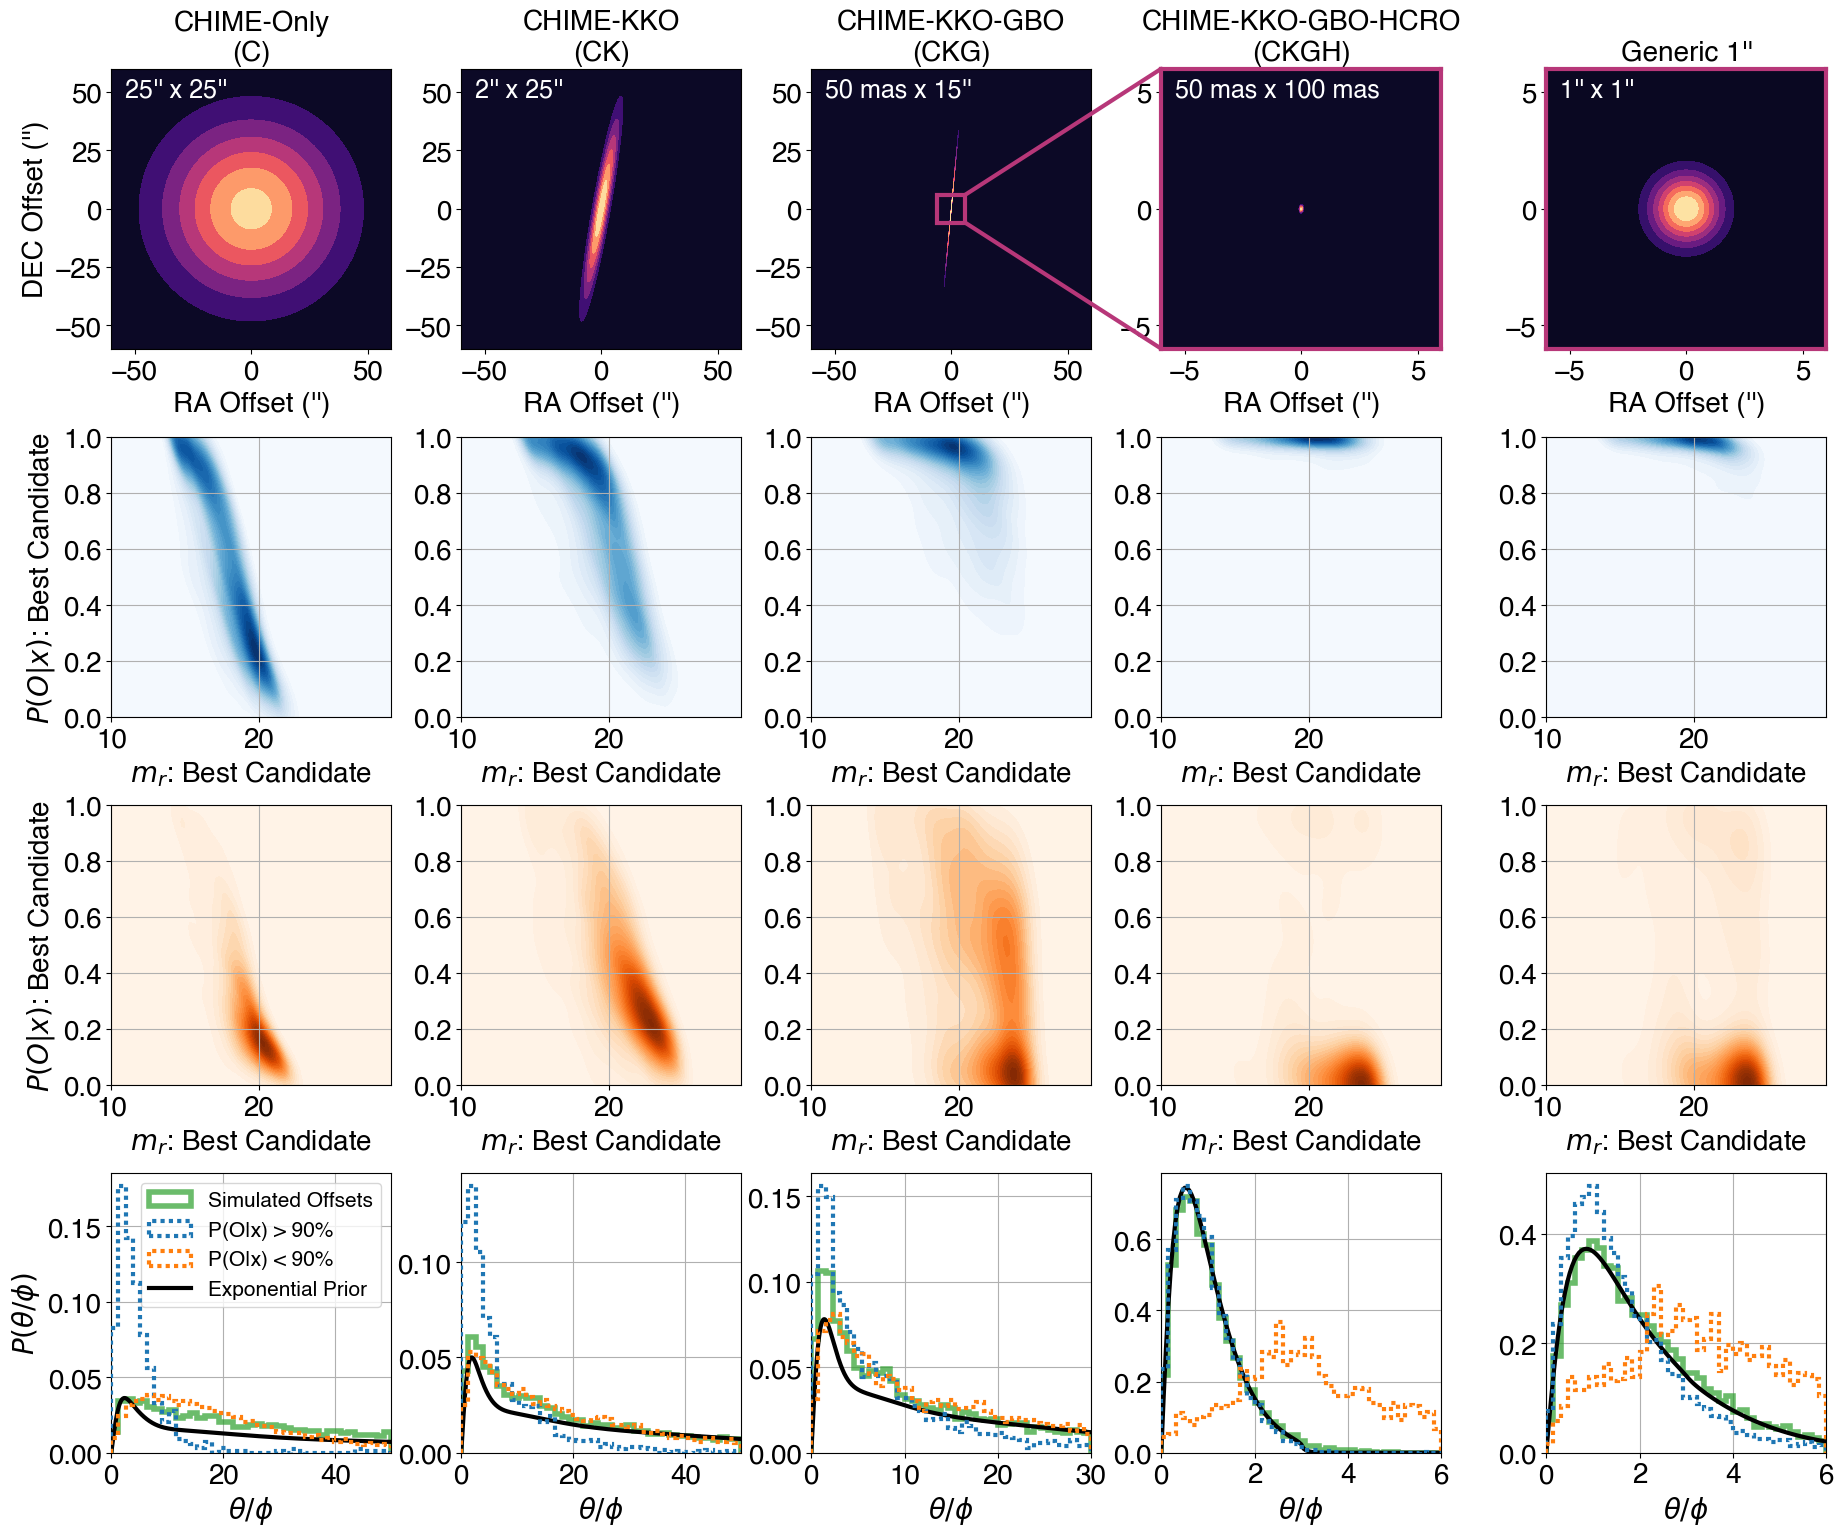

In [8]:
width_tot = 7*2
height_tot = 11*2
fig = plt.figure(figsize=(width_tot,height_tot))

###########################################################################################
################################## Plot Localizations #####################################
###########################################################################################
print('Plotting Localization PDFs')

# (left, bottom, width, height)
width = 1/5.
sep_w = 0.05
height_loc = width * width_tot/height_tot
baseband_loc = (0., 0.8, width, height_loc)
kko_loc = ((width + sep_w), 0.8, width, height_loc)
gbo_loc = ((width + sep_w)*2, 0.8, width, height_loc)
hco_loc = ((width + sep_w)*3, 0.8, width, height_loc)
dsa_loc = ((width + sep_w)*4.1, 0.8, width, height_loc)

print('CHIME-Only')
ax_baseband = plt.axes(baseband_loc)
plt.contourf(xv, yv, pdf_baseband, levels=7, cmap='magma')
plt.xlabel("RA Offset ('')")
plt.ylabel("DEC Offset ('')")
plt.title('CHIME-Only\n(C)')
plt.text(0.05, 0.9, "25'' x 25''", color='white', fontsize=18, transform=ax_baseband.transAxes)

print('CHIME-KKO')
ax_kko = plt.axes(kko_loc)
plt.contourf(xv, yv, pdf_kko, levels=7, cmap='magma')
plt.xlabel("RA Offset ('')")
plt.title('CHIME-KKO\n(CK)')
plt.text(0.05, 0.9, "2'' x 25''", color='white', fontsize=18, transform=ax_kko.transAxes)

print('CHIME-KKO-GBO')
ax_gbo = plt.axes(gbo_loc)
plt.contourf(xv, yv, pdf_gbo, levels=7, cmap='magma')
plt.xlabel("RA Offset ('')")
plt.title('CHIME-KKO-GBO\n(CKG)')
plt.text(0.05, 0.9, "50 mas x 15''", color='white', fontsize=18, transform=ax_gbo.transAxes)

print('CHIME-KKO-GBO-HCRO')
ax_hco = plt.axes(hco_loc)
plt.contourf(xv, yv, pdf_hco, levels=7, cmap='magma')
plt.xlabel("RA Offset ('')")
# ax.set_yticklabels([])
plt.xlim(-6, 6)
plt.ylim(-6, 6)
plt.title('CHIME-KKO-GBO-HCRO\n(CKGH)')
plt.text(0.05, 0.9, "50 mas x 100 mas", color='white', fontsize=18, transform=ax_hco.transAxes)

print('1"')
ax_dsa = plt.axes(dsa_loc)
plt.contourf(xv, yv, pdf_dsa, levels=7, cmap='magma')
plt.xlabel("RA Offset ('')")
plt.xlim(-6, 6)
plt.ylim(-6, 6)
plt.title("Generic 1''")
plt.text(0.05, 0.9, "1'' x 1''", color='white', fontsize=18, transform=ax_dsa.transAxes)

# --- Zoom box ---
from matplotlib.patches import Rectangle
from matplotlib.patches import ConnectionPatch

# The zoom region on GBO corresponds to the HCO axis limits
zoom_x1, zoom_x2 = -6, 6   # match ax_hco xlim
zoom_y1, zoom_y2 = -6, 6   # match ax_hco ylim

# Draw rectangle on GBO panel
rect = Rectangle(
    (zoom_x1, zoom_y1),
    zoom_x2 - zoom_x1,
    zoom_y2 - zoom_y1,
    linewidth=3, edgecolor='#b73779', facecolor='none', linestyle='-'
)
ax_gbo.add_patch(rect)

# Connect top-right corner of rectangle to top-left corner of HCO axes
# Corners: pick two that make visual sense given the panels are side by side
# Here we connect the right-side corners of the zoom box to the left-side of HCO
for gbo_corner, hco_corner in [
    ((zoom_x2, zoom_y2), (0, 1)),   # top-right GBO -> top-left HCO (axes coords)
    ((zoom_x2, zoom_y1), (0, 0)),   # bottom-right GBO -> bottom-left HCO
]:
    con = ConnectionPatch(
        xyA=gbo_corner, coordsA=ax_gbo.transData,
        xyB=hco_corner, coordsB=ax_hco.transAxes,
        color='#b73779', linewidth=3, linestyle='-'
    ) # #eb5760 or #b73779
    plt.gcf().add_artist(con)
    
for ax in [ax_hco, ax_dsa]:
    for spine in ax.spines.values():
        spine.set_edgecolor('#b73779')
        spine.set_linewidth(3)
    ax.set_yticks([-5, 0, 5])

###########################################################################################
################################ Plot Correct Magnitudes ##################################
###########################################################################################

print("Plotting P(O|x) vs magnitude for correct associations")

# (left, bottom, width, height)
width = 1/5.
sep_w = 0.05
height_loc = width * width_tot/height_tot
sep_h = 0.04
baseband_tmag = (0., 0.8-(height_loc+sep_h), width, height_loc)
kko_tmag = ((width + sep_w), 0.8-(height_loc+sep_h), width, height_loc)
gbo_tmag = ((width + sep_w)*2, 0.8-(height_loc+sep_h), width, height_loc)
hco_tmag = ((width + sep_w)*3, 0.8-(height_loc+sep_h), width, height_loc)
dsa_tmag = ((width + sep_w)*4.1, 0.8-(height_loc+sep_h), width, height_loc)

print('CHIME-Only')
ax = plt.axes(baseband_tmag)
digest = df_baseband
correct_associations = digest[digest['correct_association']]
incorrect_associations = digest[~digest['correct_association']]
# Number of contour levels
n_levels = 30
x = correct_associations['mag_cand']
y = correct_associations['P_Ox']
xmin, xmax = 10, 29
ymin, ymax = 0, 1
# Peform the kernel density estimate
xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
values = np.vstack([x, y])
kernel = stats.gaussian_kde(values)
f = np.reshape(kernel(positions).T, xx.shape)
cfset = plt.contourf(xx, yy, f, cmap='Blues', levels=n_levels, extent=[xmin, xmax, ymin, ymax])
plt.xlabel(r'$m_r$: Best Candidate')
plt.ylabel(r'$P(O|x)$: Best Candidate')
plt.grid(zorder=20)

print('CHIME-KKO')
ax = plt.axes(kko_tmag)
digest = df_kko
correct_associations = digest[digest['correct_association']]
incorrect_associations = digest[~digest['correct_association']]
# Number of contour levels
n_levels = 30
x = correct_associations['mag_cand']
y = correct_associations['P_Ox']
xmin, xmax = 10, 29
ymin, ymax = 0, 1
# Peform the kernel density estimate
xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
values = np.vstack([x, y])
kernel = stats.gaussian_kde(values)
f = np.reshape(kernel(positions).T, xx.shape)
cfset = plt.contourf(xx, yy, f, cmap='Blues', levels=n_levels, extent=[xmin, xmax, ymin, ymax])
plt.xlabel(r'$m_r$: Best Candidate')
plt.grid(zorder=20)

print('CHIME-KKO-GBO')
ax = plt.axes(gbo_tmag)
digest = df_gbo
correct_associations = digest[digest['correct_association']]
incorrect_associations = digest[~digest['correct_association']]
# Number of contour levels
n_levels = 30
x = correct_associations['mag_cand']
y = correct_associations['P_Ox']
xmin, xmax = 10, 29
ymin, ymax = 0, 1
# Peform the kernel density estimate
xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
values = np.vstack([x, y])
kernel = stats.gaussian_kde(values)
f = np.reshape(kernel(positions).T, xx.shape)
cfset = plt.contourf(xx, yy, f, cmap='Blues', levels=n_levels, extent=[xmin, xmax, ymin, ymax])
plt.xlabel(r'$m_r$: Best Candidate')
plt.grid(zorder=20)

print('1"')
ax = plt.axes(dsa_tmag)
digest = df_dsa
correct_associations = digest[digest['correct_association']]
incorrect_associations = digest[~digest['correct_association']]
# Number of contour levels
n_levels = 30
x = correct_associations['mag_cand']
y = correct_associations['P_Ox']
xmin, xmax = 10, 29
ymin, ymax = 0, 1
# Peform the kernel density estimate
xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
values = np.vstack([x, y])
kernel = stats.gaussian_kde(values)
f = np.reshape(kernel(positions).T, xx.shape)
cfset = plt.contourf(xx, yy, f, cmap='Blues', levels=n_levels, extent=[xmin, xmax, ymin, ymax])
plt.xlabel(r'$m_r$: Best Candidate')
plt.grid(zorder=20)

print('CHIME-KKO-GBO-HCRO')
ax = plt.axes(hco_tmag)
digest = df_hco
correct_associations = digest[digest['correct_association']]
incorrect_associations = digest[~digest['correct_association']]
# Number of contour levels
n_levels = 30
x = correct_associations['mag_cand']
y = correct_associations['P_Ox']
xmin, xmax = 10, 29
ymin, ymax = 0, 1
# Peform the kernel density estimate
xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
values = np.vstack([x, y])
kernel = stats.gaussian_kde(values)
f = np.reshape(kernel(positions).T, xx.shape)
cfset = plt.contourf(xx, yy, f, cmap='Blues', levels=n_levels, extent=[xmin, xmax, ymin, ymax])
plt.xlabel(r'$m_r$: Best Candidate')
plt.grid(zorder=20)

###########################################################################################
################################# Plot False Magnitudes ####################################
###########################################################################################

print("Plotting P(O|x) vs magnitude for incorrect associations")

# (left, bottom, width, height)
width = 1/5.
sep_w = 0.05
height_loc = width * width_tot/height_tot
sep_h = 0.04
baseband_fmag = (0., 0.8-(height_loc+sep_h)*2, width, height_loc)
kko_fmag = ((width + sep_w), 0.8-(height_loc+sep_h)*2, width, height_loc)
gbo_fmag = ((width + sep_w)*2, 0.8-(height_loc+sep_h)*2, width, height_loc)
hco_fmag = ((width + sep_w)*3, 0.8-(height_loc+sep_h)*2, width, height_loc)
dsa_fmag = ((width + sep_w)*4.1, 0.8-(height_loc+sep_h)*2, width, height_loc)

print('CHIME-Only')
ax = plt.axes(baseband_fmag)
digest = df_baseband
correct_associations = digest[digest['correct_association']]
incorrect_associations = digest[~digest['correct_association']]
# Number of contour levels
n_levels = 30
x = incorrect_associations['mag_cand']
y = incorrect_associations['P_Ox']
xmin, xmax = 10, 29
ymin, ymax = 0, 1
# Peform the kernel density estimate
xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
values = np.vstack([x, y])
kernel = stats.gaussian_kde(values)
f = np.reshape(kernel(positions).T, xx.shape)
cfset = plt.contourf(xx, yy, f, cmap='Oranges', levels=n_levels, extent=[xmin, xmax, ymin, ymax])
plt.xlabel(r'$m_r$: Best Candidate')
plt.ylabel(r'$P(O|x)$: Best Candidate')
plt.grid(zorder=20)

print('CHIME-KKO')
ax = plt.axes(kko_fmag)
digest = df_kko
correct_associations = digest[digest['correct_association']]
incorrect_associations = digest[~digest['correct_association']]
# Number of contour levels
n_levels = 30
x = incorrect_associations['mag_cand']
y = incorrect_associations['P_Ox']
xmin, xmax = 10, 29
ymin, ymax = 0, 1
# Peform the kernel density estimate
xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
values = np.vstack([x, y])
kernel = stats.gaussian_kde(values)
f = np.reshape(kernel(positions).T, xx.shape)
cfset = plt.contourf(xx, yy, f, cmap='Oranges', levels=n_levels, extent=[xmin, xmax, ymin, ymax])
plt.xlabel(r'$m_r$: Best Candidate')
plt.grid(zorder=20)

print('CHIME-KKO-GBO')
ax = plt.axes(gbo_fmag)
digest = df_gbo
correct_associations = digest[digest['correct_association']]
incorrect_associations = digest[~digest['correct_association']]
# Number of contour levels
n_levels = 30
x = incorrect_associations['mag_cand']
y = incorrect_associations['P_Ox']
xmin, xmax = 10, 29
ymin, ymax = 0, 1
# Peform the kernel density estimate
xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
values = np.vstack([x, y])
kernel = stats.gaussian_kde(values)
f = np.reshape(kernel(positions).T, xx.shape)
cfset = plt.contourf(xx, yy, f, cmap='Oranges', levels=n_levels, extent=[xmin, xmax, ymin, ymax])
plt.xlabel(r'$m_r$: Best Candidate')
plt.grid(zorder=20)

print('1"')
ax = plt.axes(dsa_fmag)
digest = df_dsa
correct_associations = digest[digest['correct_association']]
incorrect_associations = digest[~digest['correct_association']]
# Number of contour levels
n_levels = 30
x = incorrect_associations['mag_cand']
y = incorrect_associations['P_Ox']
xmin, xmax = 10, 29
ymin, ymax = 0, 1
# Peform the kernel density estimate
xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
values = np.vstack([x, y])
kernel = stats.gaussian_kde(values)
f = np.reshape(kernel(positions).T, xx.shape)
cfset = plt.contourf(xx, yy, f, cmap='Oranges', levels=n_levels, extent=[xmin, xmax, ymin, ymax])
plt.xlabel(r'$m_r$: Best Candidate')
plt.grid(zorder=20)

print('CHIME-KKO-GBO-HCRO')
ax = plt.axes(hco_fmag)
digest = df_hco
correct_associations = digest[digest['correct_association']]
incorrect_associations = digest[~digest['correct_association']]
# Number of contour levels
n_levels = 30
x = incorrect_associations['mag_cand']
y = incorrect_associations['P_Ox']
xmin, xmax = 10, 29
ymin, ymax = 0, 1
# Peform the kernel density estimate
xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
values = np.vstack([x, y])
kernel = stats.gaussian_kde(values)
f = np.reshape(kernel(positions).T, xx.shape)
cfset = plt.contourf(xx, yy, f, cmap='Oranges', levels=n_levels, extent=[xmin, xmax, ymin, ymax])
plt.xlabel(r'$m_r$: Best Candidate')
plt.grid(zorder=20)

# ###########################################################################################
# ##################################### Plot Offsets ########################################
# ###########################################################################################

print('Plotting galactocentric offset distributions')

# (left, bottom, width, height)
width = 1/5.
sep_w = 0.05
height_loc = width * width_tot/height_tot
sep_h = 0.04
baseband_toff = (0., 0.8-(height_loc+sep_h)*3, width, height_loc)
kko_toff = ((width + sep_w), 0.8-(height_loc+sep_h)*3, width, height_loc)
gbo_toff = ((width + sep_w)*2, 0.8-(height_loc+sep_h)*3, width, height_loc)
hco_toff = ((width + sep_w)*3, 0.8-(height_loc+sep_h)*3, width, height_loc)
dsa_toff = ((width + sep_w)*4.1, 0.8-(height_loc+sep_h)*3, width, height_loc)

lw=4
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
bins = np.linspace(0, 10, 25)
density = True

print('CHIME-Only')
ax = plt.axes(baseband_toff)
digest = df_baseband
# Calculate PATH prior convolved with localization
theta_phi = np.arange(0, 100, 0.05)
theta_prior = {'PDF': 'exp', 'scale': 0.5, 'max': 6.}
# Convolved prior for the localization region
theta_phi_conv, prior_conv = sim_utils.stack_convolved_prior(theta_phi, theta_prior, digest[:100], phi_col='ang_size_host')
# Set bins and x-axis zoom
theta_max = int(2*np.nanmax([digest['a'],digest['b']]))
theta_max = np.nanmax([theta_max, 6])
bins = np.linspace(0, theta_max, 40)
density = True
# Plot the true simulated offset distribution
_ = plt.hist(digest['sep_host_loc_norm'], bins=bins, density=density, lw=lw, edgecolor=cycle[2], fill=False, histtype='step', alpha=0.7, label='Simulated Offsets')
# Plot distribution for P(O|x) > 90%
mask = (digest['P_Ox'] > 0.9)
_ = plt.hist(digest['sep_best_loc_norm'][mask], bins=bins, density=density, lw=3, linestyle=(0, (1, 1)), histtype='step', color=cycle[0], alpha=1., label='P(O|x) > 90%', zorder=30) # hatch='//', 
# Plot distribution for P(O|x) < 90%
mask = (digest['P_Ox'] < 0.9)
_ = plt.hist(digest['sep_best_loc_norm'][mask], bins=bins, density=density, lw=3, linestyle=(0, (1, 1)), histtype='step', color=cycle[1], alpha=1., label='P(O|x) < 90%', zorder=30) # hatch='\\\\',
# Plot the prior
plt.plot(theta_phi_conv, prior_conv, lw=3, color='xkcd:black', label='Exponential Prior')
plt.xlabel(r'$\theta/\phi$')
plt.ylabel(r'$P(\theta/\phi)$')
plt.legend(fontsize=15)
plt.xlim([0,theta_max])
plt.grid(zorder=20)

print('CHIME-KKO')
ax = plt.axes(kko_toff)
digest = df_kko
# Calculate PATH prior convolved with localization
theta_phi = np.arange(0, 100, 0.05)
theta_prior = {'PDF': 'exp', 'scale': 0.5, 'max': 6.}
# Convolved prior for the localization region
theta_phi_conv, prior_conv = sim_utils.stack_convolved_prior(theta_phi, theta_prior, digest[:100], phi_col='ang_size_host')
# Set bins and x-axis zoom
theta_max = int(2*np.nanmax([digest['a'],digest['b']]))
theta_max = np.nanmax([theta_max, 6])
bins = np.linspace(0, theta_max, 40)
density = True
# Plot the true simulated offset distribution
_ = plt.hist(digest['sep_host_loc_norm'], bins=bins, density=density, lw=lw, edgecolor=cycle[2], fill=False, histtype='step', alpha=0.7, label='Simulated Offsets')
# Plot distribution for P(O|x) > 90%
mask = (digest['P_Ox'] > 0.9)
_ = plt.hist(digest['sep_best_loc_norm'][mask], bins=bins, density=density, lw=3, linestyle=(0, (1, 1)), histtype='step', color=cycle[0], alpha=1., label='P(O|x) > 90%', zorder=30) # hatch='//', 
# Plot distribution for P(O|x) < 90%
mask = (digest['P_Ox'] < 0.9)
_ = plt.hist(digest['sep_best_loc_norm'][mask], bins=bins, density=density, lw=3, linestyle=(0, (1, 1)), histtype='step', color=cycle[1], alpha=1., label='P(O|x) < 90%', zorder=30) # hatch='\\\\',
# Plot the prior
plt.plot(theta_phi_conv, prior_conv, lw=3, color='xkcd:black', label='Exponential Prior')
plt.xlabel(r'$\theta/\phi$')
plt.xlim([0,theta_max])
plt.grid(zorder=20)

print('CHIME-KKO-GBO')
ax = plt.axes(gbo_toff)
digest = df_gbo
# Calculate PATH prior convolved with localization
theta_phi = np.arange(0, 100, 0.05)
theta_prior = {'PDF': 'exp', 'scale': 0.5, 'max': 6.}
# Convolved prior for the localization region
theta_phi_conv, prior_conv = sim_utils.stack_convolved_prior(theta_phi, theta_prior, digest[:100], phi_col='ang_size_host')
# Set bins and x-axis zoom
theta_max = int(2*np.nanmax([digest['a'],digest['b']]))
theta_max = np.nanmax([theta_max, 6])
bins = np.linspace(0, theta_max, 40)
density = True
# Plot the true simulated offset distribution
_ = plt.hist(digest['sep_host_loc_norm'], bins=bins, density=density, lw=lw, edgecolor=cycle[2], fill=False, histtype='step', alpha=0.7, label='Simulated Offsets')
# Plot distribution for P(O|x) > 90%
mask = (digest['P_Ox'] > 0.9)
_ = plt.hist(digest['sep_best_loc_norm'][mask], bins=bins, density=density, lw=3, linestyle=(0, (1, 1)), histtype='step', color=cycle[0], alpha=1., label='P(O|x) > 90%', zorder=30) # hatch='//', 
# Plot distribution for P(O|x) < 90%
mask = (digest['P_Ox'] < 0.9)
_ = plt.hist(digest['sep_best_loc_norm'][mask], bins=bins, density=density, lw=3, linestyle=(0, (1, 1)), histtype='step', color=cycle[1], alpha=1., label='P(O|x) < 90%', zorder=30) # hatch='\\\\',
# Plot the prior
plt.plot(theta_phi_conv, prior_conv, lw=3, color='xkcd:black', label='Exponential Prior')
plt.xlabel(r'$\theta/\phi$')
plt.xlim([0,theta_max])
plt.grid(zorder=20)

print('1"')
ax = plt.axes(dsa_toff)
digest = df_dsa
# Calculate PATH prior convolved with localization
theta_phi = np.arange(0, 100, 0.05)
theta_prior = {'PDF': 'exp', 'scale': 0.5, 'max': 6.}
# Convolved prior for the localization region
theta_phi_conv, prior_conv = sim_utils.stack_convolved_prior(theta_phi, theta_prior, digest[:100], phi_col='ang_size_host')
# Set bins and x-axis zoom
theta_max = int(2*np.nanmax([digest['a'],digest['b']]))
theta_max = np.nanmax([theta_max, 6])
bins = np.linspace(0, theta_max, 40)
density = True
# Plot the true simulated offset distribution
_ = plt.hist(digest['sep_host_loc_norm'], bins=bins, density=density, lw=lw, edgecolor=cycle[2], fill=False, histtype='step', alpha=0.7, label='Simulated Offsets')
# Plot distribution for P(O|x) > 90%
mask = (digest['P_Ox'] > 0.9)
_ = plt.hist(digest['sep_best_loc_norm'][mask], bins=bins, density=density, lw=3, linestyle=(0, (1, 1)), histtype='step', color=cycle[0], alpha=1., label='P(O|x) > 90%', zorder=30) # hatch='//', 
# Plot distribution for P(O|x) < 90%
mask = (digest['P_Ox'] < 0.9)
_ = plt.hist(digest['sep_best_loc_norm'][mask], bins=bins, density=density, lw=3, linestyle=(0, (1, 1)), histtype='step', color=cycle[1], alpha=1., label='P(O|x) < 90%', zorder=30) # hatch='\\\\',
# Plot the prior
plt.plot(theta_phi_conv, prior_conv, lw=3, color='xkcd:black', label='Exponential Prior')
plt.xlabel(r'$\theta/\phi$')
plt.xlim([0,theta_max])
plt.grid(zorder=20)

print('CHIME-KKO-GBO-HCRO')
ax = plt.axes(hco_toff)
digest = df_hco
# Calculate PATH prior convolved with localization
theta_phi = np.arange(0, 100, 0.05)
theta_prior = {'PDF': 'exp', 'scale': 0.5, 'max': 6.}
# Convolved prior for the localization region
theta_phi_conv, prior_conv = sim_utils.stack_convolved_prior(theta_phi, theta_prior, digest[:100], phi_col='ang_size_host')
# Set bins and x-axis zoom
theta_max = int(2*np.nanmax([digest['a'],digest['b']]))
theta_max = np.nanmax([theta_max, 6])
bins = np.linspace(0, theta_max, 40)
density = True
# Plot the true simulated offset distribution
_ = plt.hist(digest['sep_host_loc_norm'], bins=bins, density=density, lw=lw, edgecolor=cycle[2], fill=False, histtype='step', alpha=0.7, label='Simulated Offsets')
# Plot distribution for P(O|x) > 90%
mask = (digest['P_Ox'] > 0.9)
_ = plt.hist(digest['sep_best_loc_norm'][mask], bins=bins, density=density, lw=3, linestyle=(0, (1, 1)), histtype='step', color=cycle[0], alpha=1., label='P(O|x) > 90%', zorder=30) # hatch='//', 
# Plot distribution for P(O|x) < 90%
mask = (digest['P_Ox'] < 0.9)
_ = plt.hist(digest['sep_best_loc_norm'][mask], bins=bins, density=density, lw=3, linestyle=(0, (1, 1)), histtype='step', color=cycle[1], alpha=1., label='P(O|x) < 90%', zorder=30) # hatch='\\\\',
# Plot the prior
plt.plot(theta_phi_conv, prior_conv, lw=3, color='xkcd:black', label='Exponential Prior')
plt.xlabel(r'$\theta/\phi$')
plt.xlim([0,theta_max])
plt.grid(zorder=20)

print('Saving plot')
plot_fn = os.path.join(os.getenv('FRB_APATH'), 'paper_figures', 'sim_pdf_mags_redo_draft2_nolabels.pdf')
plt.savefig(plot_fn, dpi=200, format="pdf", bbox_inches="tight")

## Figure 7

In [9]:
# First, load in the pre-queried DECaL galaxy catalog
fn = 'catalog_dudxmmlss_hecate_DECaL.parquet'
path_catalog_fn = Path(os.getenv('FRB_APATH')) / fn
if path_catalog_fn.exists():
    path_catalog = load_galaxy_catalog(catalog_fn=fn)
else:
    raise FileNotFoundError(f"The file {fn} does not exist")

Loading real galaxy catalog from:
  /Users/bandersen/Documents/CHIME/notebooks/path_simulations/catalogs/catalog_dudxmmlss_hecate_DECaL.parquet


In [11]:
# Load in simulations digest for each localization region
fn = os.path.join(os.getenv('FRB_APATH'), 'final_sims', 'digest_a25b2pa12_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_final.parquet')
digest = pd.read_parquet(fn)
digest_filt = digest
# digest_filt = sim_utils.calculate_unseen(digest, path_catalog, thresh_cross_match=2.)

In [12]:
# Calculate the fraction unseen in each magnitude bin
mag_bin_edges = np.arange(10.5, 28., 1.)
mag_bin_centers = (mag_bin_edges[:-1] + mag_bin_edges[1:]) / 2.

# Jackknife to get errors
N = 500
unseen_jn_data_decals = []
for kk in range(N):
    # Remove 1/5 of points
    inds = random.sample(range(len(digest_filt)), int(len(digest_filt)/5))
    digest_jn = digest_filt.iloc[inds]
    
    unseen_fraction = []
    for ii in range(len(mag_bin_edges)-1):
        mag_start_bin = mag_bin_edges[ii]
        mag_end_bin = mag_bin_edges[ii+1]
        in_bin = (digest_jn['mag_host'] >= mag_start_bin) & (digest_jn['mag_host'] <= mag_end_bin)
        digest_in_bin = digest_jn[in_bin]
        digest_unseen = digest_in_bin[digest_in_bin['unseen']]
        if len(digest_in_bin) == 0:
            unseen_frac = np.nan
        elif mag_start_bin < 14.5:
            unseen_frac = 0.
        else:
            unseen_frac = len(digest_unseen) / len(digest_in_bin)
        unseen_fraction.append(unseen_frac)
    mag_bin_centers = (mag_bin_edges[:-1] + mag_bin_edges[1:]) / 2.
    unseen_jn_data_decals.append(unseen_fraction)

In [144]:
# Now, do the same for the pre-queried Pan-STARRS galaxy catalog
fn = 'catalog_dudxmmlss_hecate_Pan-STARRS.parquet'
path_catalog_fn = Path(os.getenv('FRB_APATH')) / fn
if path_catalog_fn.exists():
    path_catalog = load_galaxy_catalog(catalog_fn=fn)
else:
    raise FileNotFoundError(f"The file {fn} does not exist")

Loading real galaxy catalog from:
  /Users/bandersen/Documents/CHIME/notebooks/path_simulations/catalogs/catalog_dudxmmlss_hecate_Pan-STARRS.parquet


In [145]:
# Load in simulations digest for each localization region
fn = os.path.join(os.getenv('FRB_APATH'), 'digest_a25b2pa12_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL.parquet')
digest = pd.read_parquet(fn)
digest_filt = sim_utils.calculate_unseen(digest, path_catalog, thresh_cross_match=2.)

Starting cross-matching (will take a minute)...
Cross-matching finished. Time elapsed: 0.284 minutes


In [13]:
# Calculate the fraction unseen in each magnitude bin
mag_bin_edges = np.arange(10.5, 28., 1.)
mag_bin_centers = (mag_bin_edges[:-1] + mag_bin_edges[1:]) / 2.

# Jackknife to get errors
N = 500
unseen_jn_data_ps1 = []
for kk in range(N):
    # Remove 1/5 of points
    inds = random.sample(range(len(digest_filt)), int(len(digest_filt)/5))
    digest_jn = digest_filt.iloc[inds]
    
    unseen_fraction = []
    for ii in range(len(mag_bin_edges)-1):
        mag_start_bin = mag_bin_edges[ii]
        mag_end_bin = mag_bin_edges[ii+1]
        in_bin = (digest_jn['mag_host'] >= mag_start_bin) & (digest_jn['mag_host'] <= mag_end_bin)
        digest_in_bin = digest_jn[in_bin]
        digest_unseen = digest_in_bin[digest_in_bin['unseen']]
        if len(digest_in_bin) == 0:
            unseen_frac = np.nan
        elif mag_start_bin < 14.5:
            unseen_frac = 0.
        else:
            unseen_frac = len(digest_unseen) / len(digest_in_bin)
        unseen_fraction.append(unseen_frac)
    mag_bin_centers = (mag_bin_edges[:-1] + mag_bin_edges[1:]) / 2.
    unseen_jn_data_ps1.append(unseen_fraction)

In [14]:
# Load in generated FRBs for each of the relevant telescopes
generated_frbs_fn = os.path.join(os.getenv('FRB_APATH'), 'generated_frbs_chime.parquet')
frbs_chime = pd.read_parquet(generated_frbs_fn)

generated_frbs_fn = os.path.join(os.getenv('FRB_APATH'), 'generated_frbs_dsa.parquet')
frbs_dsa = pd.read_parquet(generated_frbs_fn)

generated_frbs_fn = os.path.join(os.getenv('FRB_APATH'), 'generated_frbs_craftics.parquet')
frbs_askap = pd.read_parquet(generated_frbs_fn)

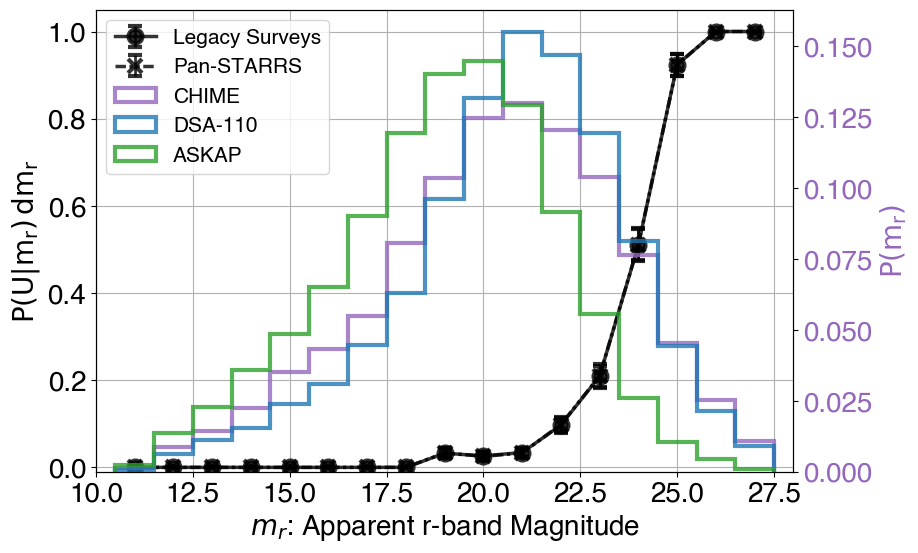

In [15]:
# Now plot!
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = [cycle[0], cycle[1], cycle[2], cycle[4], 'black']
markers = ['x', '+', 'd', '*', 'o']
marker_sizes = [100, 150, 80, 100, 80]
linestyles = ['-', '--', '-.', (0, (3, 1, 1, 1, 1, 1)), (0, (1, 1))]

fig = plt.figure(figsize=(9,6))

# Plot P(U) dm_r
ax1 = plt.gca()
plt.errorbar(
    mag_bin_centers, np.nanmean(unseen_jn_data_decals, axis=0) / np.nanmax(np.nanmean(unseen_jn_data_decals, axis=0)), yerr=np.nanstd(unseen_jn_data_decals, axis=0), 
    capsize=5, elinewidth=2, lw=2.5, markersize=marker_sizes[0]/10, mew=3, color='black', 
    marker='o', alpha=0.8, label='Legacy Surveys',
) 
plt.errorbar(
    mag_bin_centers, np.nanmean(unseen_jn_data_ps1, axis=0) / np.nanmax(np.nanmean(unseen_jn_data_ps1, axis=0)), yerr=np.nanstd(unseen_jn_data_ps1, axis=0), 
    capsize=5, elinewidth=2, lw=2.5, markersize=marker_sizes[0]/10, mew=3, color='black', 
    marker='x', alpha=0.8, label='Pan-STARRS', linestyle=linestyles[-2],
) 
plt.ylabel(r'$\rm P(U|m_r)\,dm_r$')
plt.xlim([10,28])
plt.ylim([-0.01,1.05])
plt.grid(zorder=20)
plt.xlabel('$m_r$: Apparent r-band Magnitude')
lines, labels = ax1.get_legend_handles_labels()

# Plot the CHIME magnitude distribution
ax2 = ax1.twinx()
bins = np.arange(10.5, 28., 1.)
density = True
Ns_chime, bins, _ = plt.hist(
    frbs_chime['m_r'], bins=bins, density=density, 
    histtype='step', lw=3,
    color=colors[-2], alpha=0.8, label='CHIME',
)
Ns_dsa, bins, _ = plt.hist(
    frbs_dsa['m_r'], bins=bins, density=density, 
    histtype='step', lw=3,
    color=colors[0], alpha=0.8, label='DSA-110',
)
Ns_askap, bins, _ = plt.hist(
    frbs_askap['m_r'], bins=bins, density=density, 
    histtype='step', lw=3,
    color=colors[2], alpha=0.8, label='ASKAP', 
)
ax2.tick_params(axis='y', labelcolor=colors[-2])
ax2.set_ylabel(r'$\rm P(m_r)$', color=colors[-2])

lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, fontsize=15, loc='upper left')

# plot_fn = os.path.join(os.getenv('CHIME_SANDBOX'), 'simulation_results', 'plots', 'paper_plot_data', 'PU_decals_ps1.pdf')
# plt.savefig(plot_fn, dpi=200, format="pdf", bbox_inches="tight")

In [16]:
# Calculate P(U) for CHIME and DECaL
PU_dmrs = np.nanmean(unseen_jn_data_decals, axis=0)
PU = np.nansum(Ns_chime * PU_dmrs) / np.nansum(Ns_chime)
print(f"CHIME + DECaL P(U): {PU:.2f}")

CHIME + DECaL P(U): 0.16


In [17]:
# Calculate P(U) for CHIME and Pan-STARRS
PU_dmrs = np.nanmean(unseen_jn_data_ps1, axis=0)
PU = np.nansum(Ns_chime * PU_dmrs) / np.nansum(Ns_chime)
print(f"CHIME + Pan-STARRS P(U): {PU:.2f}")

CHIME + Pan-STARRS P(U): 0.16


## Figure 8

In [23]:
P_Us = np.linspace(0., 1., 11)
P_Us

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

In [33]:
survey_str = 'DECaL'
P_Ox_thresh = 0.9
P_Us = np.linspace(0., 1., 10)

fp_rates_all = {}
tp_rates_all = {}
for loc in ['a25b25pa0', 'a25b2pa12', 'a15b0pa5', 'a1b1pa0', 'a0b0pa10']:
    fp_rates = []
    tp_rates = []
    print(loc)
    for P_U in P_Us:
        if P_U == 1:
            fp_rates.append(0)
            tp_rates.append(0)
            continue
        fn = os.path.join(os.getenv('FRB_APATH'), 'final_sims', f'digest_{loc}_exponential_exp_inverse_pu{P_U:.1f}_catalog_dudxmmlss_hecate_DECaL_10000_final.parquet')
        digest = pd.read_parquet(fn)
        
        match_criteria_TP = (digest['correct_association']) & (digest['P_Ox'] > P_Ox_thresh)
        match_criteria_FN = (digest['correct_association']) & (digest['P_Ox'] < P_Ox_thresh)
        match_criteria_FP = (~digest['correct_association']) & (digest['P_Ox'] > P_Ox_thresh)
        match_criteria_TN = (~digest['correct_association']) & (digest['P_Ox'] < P_Ox_thresh)

        N_TP = len(digest[match_criteria_TP])
        N_FN = len(digest[match_criteria_FN])
        N_FP = len(digest[match_criteria_FP])
        N_TN = len(digest[match_criteria_TN])
        
        print(f"P(U) = {P_U}")
        print(f"TP = {N_TP}, FP = {N_FP}")

        if len(digest) != 0:
            fp_rates.append(N_FP / len(digest))
            tp_rates.append(N_TP / len(digest))
        else:
            fp_rates.append(np.nan)
            tp_rates.append(np.nan)
        print(f"FP_rate = {fp_rates[-1]}")
        print(f"TP_rate = {tp_rates[-1]}")
        print()
    fp_rates_all[loc] = fp_rates
    tp_rates_all[loc] = tp_rates

a25b25pa0
P(U) = 0.0
TP = 708, FP = 219
FP_rate = 0.0219
TP_rate = 0.0708

P(U) = 0.1111111111111111
TP = 598, FP = 173
FP_rate = 0.0173
TP_rate = 0.0598

P(U) = 0.2222222222222222
TP = 511, FP = 143
FP_rate = 0.0143
TP_rate = 0.0511

P(U) = 0.3333333333333333
TP = 452, FP = 121
FP_rate = 0.0121
TP_rate = 0.0452

P(U) = 0.4444444444444444
TP = 381, FP = 101
FP_rate = 0.0101
TP_rate = 0.0381

P(U) = 0.5555555555555556
TP = 249, FP = 50
FP_rate = 0.005
TP_rate = 0.0249

P(U) = 0.6666666666666666
TP = 181, FP = 36
FP_rate = 0.0036
TP_rate = 0.0181

P(U) = 0.7777777777777777
TP = 94, FP = 14
FP_rate = 0.0014
TP_rate = 0.0094

P(U) = 0.8888888888888888
TP = 15, FP = 2
FP_rate = 0.0002
TP_rate = 0.0015

a25b2pa12
P(U) = 0.0
TP = 2479, FP = 375
FP_rate = 0.0375
TP_rate = 0.2479

P(U) = 0.1111111111111111
TP = 1988, FP = 188
FP_rate = 0.0188
TP_rate = 0.1988

P(U) = 0.2222222222222222
TP = 1672, FP = 151
FP_rate = 0.0151
TP_rate = 0.1672

P(U) = 0.3333333333333333
TP = 1421, FP = 120
FP_rate =

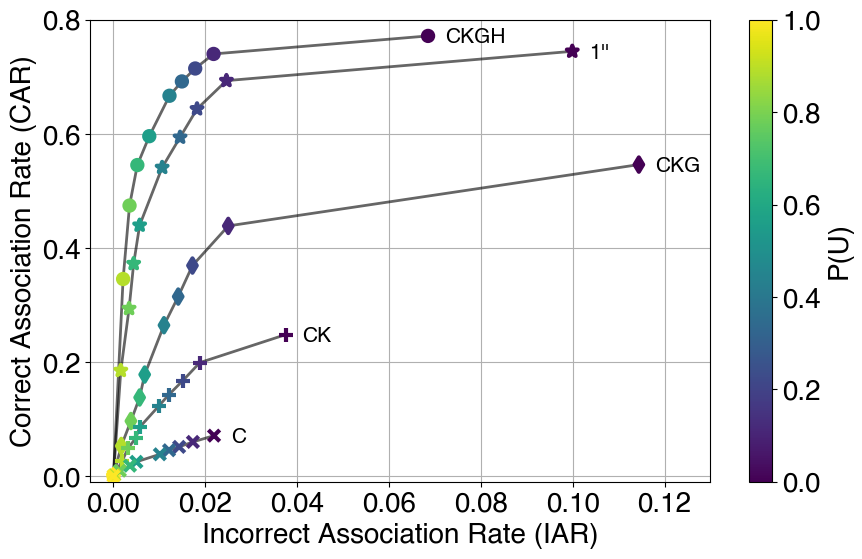

In [36]:
fig = plt.figure(figsize=(10,6))

cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = [cycle[0], cycle[1], cycle[2], 'black'] #  cycle[4], 
markers = ['x', '+', 'd', '*', 'o']
# markers = ['o', '^', 's', '*']
marker_sizes = [100, 150, 80, 100, 80]
linestyles = ['-', '--', '-.', (0, (3, 1, 1, 1, 1, 1)), (0, (1, 1))]
sims = ['a25b25pa0', 'a25b2pa12', 'a15b0pa5', 'a1b1pa0', 'a0b0pa10']
zorders = 10+np.arange(len(sims))[::-1]

for ii, loc in enumerate(sims):
    # Find ind with minimum distance from TP=1, FP=0
    fp_rates = np.array(fp_rates_all[loc])
    tp_rates = np.array(tp_rates_all[loc])
    dist = np.sqrt((fp_rates-0)**2+(tp_rates-1)**2)
    ind = np.nanargmin(dist)
    
    if loc == 'a25b25pa0':
        label = 'C'
    elif loc == 'a25b2pa12':
        label = "CK"
    elif loc == 'a15b0pa5':
        label = "CKG"
    elif loc == 'a0b0pa10':
        label = "CKGH"
    elif loc == 'a1b1pa0':
        label = "1''"
    else:
        label = f"{loc.upper()}"
    
    plt.scatter(fp_rates, tp_rates, c=P_Us, cmap='viridis', marker=markers[ii], s=marker_sizes[ii]/1.5, lw=3, zorder=zorders[ii], label=label)
    plt.plot(fp_rates, tp_rates, marker='', lw=2, color='black', alpha=0.6, zorder=zorders[ii]-1)
    
    # Put labels next to points
    idx_pu0 = np.argmin(P_Us)  # index where P(U) is closest to 0
    plt.annotate(
        label,
        xy=(fp_rates[idx_pu0], tp_rates[idx_pu0]),
        xytext=(12, -5),
        textcoords='offset points',
        fontsize=15,
        # fontweight='bold',
        color='black',
        zorder=zorders[ii]+1
    )
plt.colorbar(label='P(U)')
plt.xlim([-0.005,0.13])
plt.ylim([-0.01,0.8])
plt.grid(zorder=1)
plt.xlabel(r'Incorrect Association Rate (IAR)') # $\rm= \frac{IA}{CA + IA}$
plt.ylabel(r'Correct Association Rate (CAR)') # $\rm= \frac{CA}{CA + IA}$

plot_fn = os.path.join(os.getenv('FRB_APATH'), 'paper_figures', 'tp_vs_fp_PU_relabel2.pdf')
plt.savefig(plot_fn, dpi=200, format="pdf", bbox_inches="tight")

## Figure 9

In [9]:
# Calculate which hosts are unseen for each simulation
for jj, loc in enumerate(['a25b25pa0']):#, 'a25b2pa12', 'a15b0pa5', 'a1b1pa0', 'a0b0pa10']):
    print(f'Localization: {loc}')
    if loc == 'a25b25pa0':
        fn1 = os.path.join(os.getenv('FRB_APATH'), f'digest_{loc}_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_discretize_10arcmin.parquet')
        digest = pd.read_parquet(fn1)
        
        fn2 = os.path.join(os.getenv('FRB_APATH'), f'full_path_results_{loc}_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_discretize_10arcmin.parquet')
        full_results = pd.read_parquet(fn2)
    else:
        fn1 = os.path.join(os.getenv('FRB_APATH'), f'digest_{loc}_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_discretize_10arcmin.parquet')
        digest = pd.read_parquet(fn1)
        
        fn2 = os.path.join(os.getenv('FRB_APATH'), f'full_path_results_{loc}_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_discretize_10arcmin.parquet')
        full_results = pd.read_parquet(fn2)
    digest_unseen = sim_utils.calculate_unseen(digest, full_results, thresh_cross_match=0.5, mag_limit=None)
    fn_out = fn1.split('.parquet')[0] + '_unseen.parquet'
#     digest_unseen.to_parquet(fn_out)
    print(f'Saving to {fn_out}')

Localization: a25b25pa0
Starting cross-matching (will take a minute)...
Cross-matching finished. Time elapsed: 0.138 minutes
Saving to /Users/bandersen/Documents/CHIME/notebooks/path_simulations/catalogs/digest_a25b25pa0_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_discretize_10arcmin_unseen.parquet


Localization: a25b25pa0
Localization: a25b2pa12
Localization: a15b0pa5
Localization: a1b1pa0
Localization: a0b0pa10
Localization: offset_mismatch
Localization: mag_identical


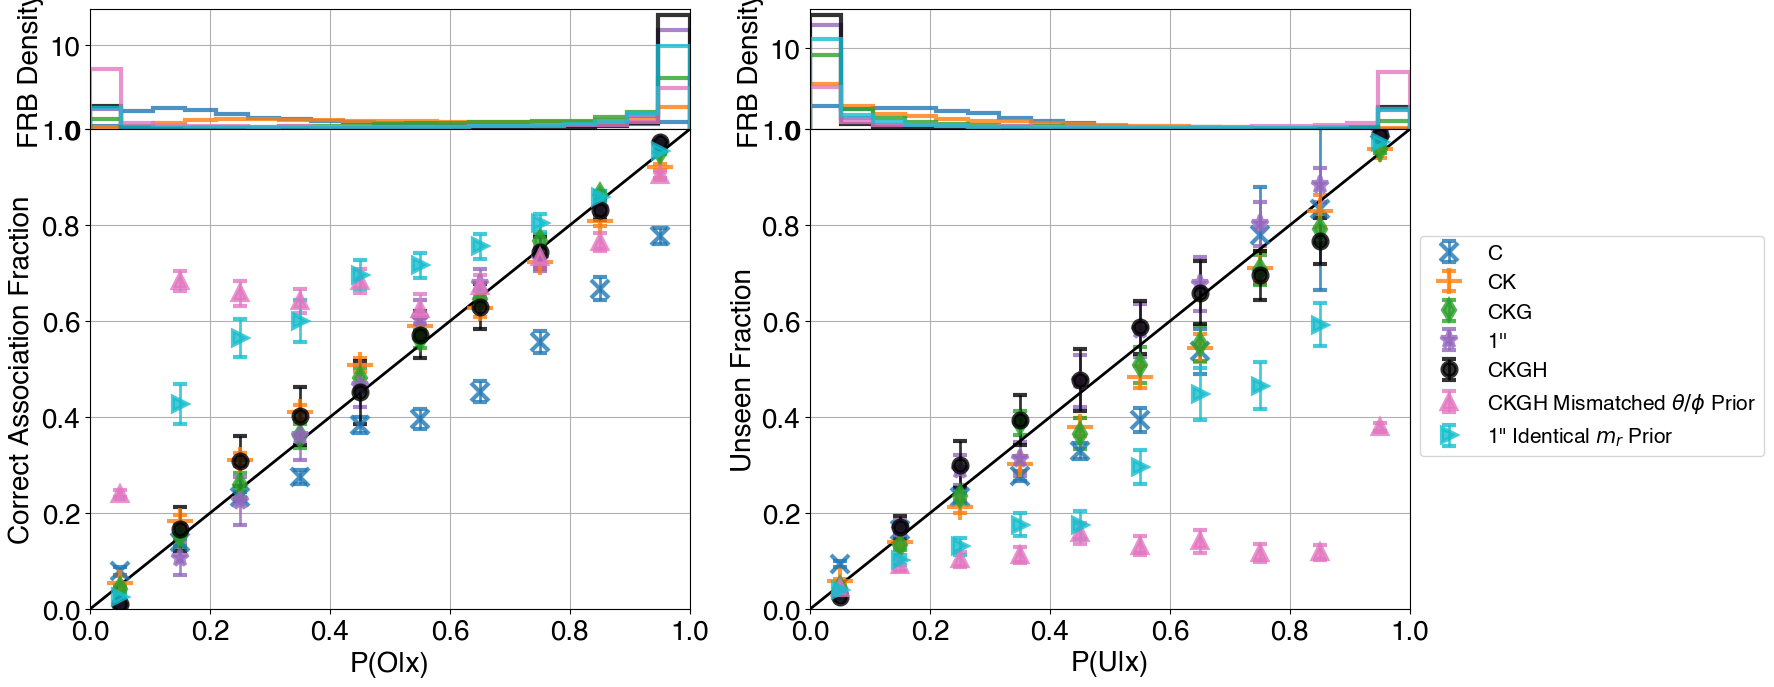

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12,6))
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = [cycle[0], cycle[1], cycle[2], cycle[4], 'black', cycle[6], cycle[9]]
markers = ['x', '+', 'd', '*', 'o', '^', '>']
marker_sizes = [100, 150, 80, 100, 80, 80, 80]

sep_w = 0.1
post_POx_ax = (0., 0., 0.5, 0.8)
hist_POx_ax = (0., 0.8, 0.5, 0.2)
post_PUx_ax = (0.5+sep_w, 0., 0.5, 0.8)
hist_PUx_ax = (0.5+sep_w, 0.8, 0.5, 0.2)

ax_hist_POx = plt.axes(hist_POx_ax)
ax_post_POx = plt.axes(post_POx_ax)
ax_hist_PUx = plt.axes(hist_PUx_ax)
ax_post_PUx = plt.axes(post_PUx_ax)

for jj, loc in enumerate(['a25b25pa0', 'a25b2pa12', 'a15b0pa5', 'a1b1pa0', 'a0b0pa10', 'offset_mismatch', 'mag_identical']):
    print(f'Localization: {loc}')
    
    if loc == 'offset_mismatch':
        fn = os.path.join(os.getenv('FRB_APATH'), 'final_sims', 'digest_a0b0pa10_uniform_1d_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_final.parquet')
    elif loc == 'mag_identical':
        fn = os.path.join(os.getenv('FRB_APATH'), 'final_sims', 'digest_a1b1pa0_exponential_exp_identical_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_final.parquet')
    else:
        fn = os.path.join(os.getenv('FRB_APATH'), 'final_sims', f'digest_{loc}_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_final.parquet')
    digest = pd.read_parquet(fn)

    # ----------------------------------------------------
    # PLOT P(O|x) POSTERIORS
    # ----------------------------------------------------
    bins = np.linspace(0,1,20)
    _ = ax_hist_POx.hist(digest['P_Ox'], bins=bins, density=True, histtype='step', lw=3, color=colors[jj], alpha=0.8)
    ax_hist_POx.set_ylabel('FRB Density')
    ax_hist_POx.set_xlim([0.,1.])
    ax_hist_POx.grid(zorder=20)
    ax_hist_POx.set_xticklabels([])

    # Bootstrap to get errors
    N_boot = 100
    tp_boot_data = []
    P_Ox_bin_edges = np.arange(0, 1.1, 0.1)
    P_Ox_bin_centers = (P_Ox_bin_edges[:-1] + P_Ox_bin_edges[1:]) / 2.

    for kk in range(N_boot):
        # Sample WITH replacement, keeping the total row count identical
        digest_boot = digest.sample(frac=1.0, replace=True)

        tp_fraction = []
        for ii in range(len(P_Ox_bin_edges)-1):
            P_Ox_start_bin = P_Ox_bin_edges[ii]
            P_Ox_end_bin = P_Ox_bin_edges[ii+1]
            in_bin = ((digest_boot['P_Ox'] >= P_Ox_start_bin) & (digest_boot['P_Ox'] <= P_Ox_end_bin)).values
            digest_in_bin = digest_boot[in_bin]
            digest_tp = digest_in_bin[digest_in_bin['correct_association']]
            
            
            if len(digest_in_bin) < 1:
                tp_frac = np.nan
            else:
                tp_frac = len(digest_tp) / len(digest_in_bin)
            tp_fraction.append(tp_frac)
            
        tp_boot_data.append(tp_fraction)
        
    if loc == 'a25b25pa0': label = 'C'
    elif loc == 'a25b2pa12': label = "CK"
    elif loc == 'a15b0pa5': label = "CKG"
    elif loc == 'a1b1pa0': label = "1''"
    elif loc == 'a0b0pa10': label = "CKGH"
    elif loc == 'offset_mismatch': label = r"CKGH Mismatched $\theta/\phi$ Prior"
    elif loc == 'mag_identical': label = r'1" Identical $m_r$ Prior'
        
    # Plot points using standard deviation directly
    ax_post_POx.errorbar(
        P_Ox_bin_centers, np.nanmedian(tp_boot_data, axis=0), yerr=np.nanstd(tp_boot_data, axis=0), 
        capsize=5, elinewidth=2, mew=3, markersize=marker_sizes[jj]/8, 
        color=colors[jj], marker=markers[jj], linestyle="None", alpha=0.8, label=label,
    ) 
    
    # ----------------------------------------------------
    # PLOT P(U|x) POSTERIORS
    # ----------------------------------------------------
    bins = np.linspace(0,1,20)
    _ = ax_hist_PUx.hist(digest['P_Ux'], bins=bins, density=True, histtype='step', lw=3, color=colors[jj], alpha=0.8)
    ax_hist_PUx.set_ylabel('FRB Density')
    ax_hist_PUx.set_xlim([0.,1.])
    ax_hist_PUx.grid(zorder=20)
    ax_hist_PUx.set_xticklabels([])

    # Bootstrap to get errors
    unseen_boot_data = []
    P_Ux_bin_edges = np.arange(0., 1.1, 0.1)
    P_Ux_bin_centers = (P_Ux_bin_edges[:-1] + P_Ux_bin_edges[1:]) / 2.

    for kk in range(N_boot):
        # Sample WITH replacement, keeping the total row count identical
        digest_boot = digest.sample(frac=1.0, replace=True)

        unseen_fraction = []
        for ii in range(len(P_Ux_bin_edges)-1):
            P_Ux_start_bin = P_Ux_bin_edges[ii]
            P_Ux_end_bin = P_Ux_bin_edges[ii+1]
            in_bin = ((digest_boot['P_Ux'] >= P_Ux_start_bin) & (digest_boot['P_Ux'] <= P_Ux_end_bin)).values
            digest_in_bin = digest_boot[in_bin]
            digest_unseen = digest_in_bin[digest_in_bin['unseen']]
            
            if len(digest_in_bin) < 1:
                unseen_frac = np.nan
            else:
                unseen_frac = len(digest_unseen) / len(digest_in_bin)
            unseen_fraction.append(unseen_frac)
            
        unseen_boot_data.append(unseen_fraction)
        
    # Plot points using standard deviation directly
    ax_post_PUx.errorbar(
        P_Ux_bin_centers, np.nanmedian(unseen_boot_data, axis=0), yerr=np.nanstd(unseen_boot_data, axis=0), 
        capsize=5, elinewidth=2, mew=3, markersize=marker_sizes[jj]/8, 
        color=colors[jj], marker=markers[jj], linestyle="None", alpha=0.8, label=label,
    ) 
    
ax_post_PUx.plot(np.arange(0,1.1,0.1), np.arange(0,1.1,0.1), lw=2, color='black')
ax_post_PUx.set_xlabel('P(U|x)')
ax_post_PUx.set_ylabel('Unseen Fraction')
ax_post_PUx.legend(fontsize=15)
ax_post_PUx.grid(zorder=20)
ax_post_PUx.set_ylim([0.,1.])
ax_post_PUx.set_xlim([0.,1.])
ax_post_PUx.legend(fontsize=15, bbox_to_anchor=[1., 0.8])

ax_post_POx.plot(np.arange(0,1.1,0.1), np.arange(0,1.1,0.1), lw=2, color='black')
ax_post_POx.set_xlabel('P(O|x)')
ax_post_POx.set_ylabel('Correct Association Fraction')
ax_post_POx.grid(zorder=20)
ax_post_POx.set_ylim([0.,1.])
ax_post_POx.set_xlim([0.,1.])

plot_fn = os.path.join(os.getenv('FRB_APATH'), 'paper_figures', 'posterior_calibration_exp_redo_relabel.pdf')
plt.savefig(plot_fn, dpi=200, format="pdf", bbox_inches="tight")

## Figure 10

In [1]:
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
params = {'axes.labelsize':20,
         'axes.titlesize':20,
         'xtick.labelsize':20,
         'ytick.labelsize':20}
pylab.rcParams.update(params)
from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
rc('text', usetex=False)
import matplotlib

import os
import pandas as pd
import numpy as np
from importlib.resources import files
from pathlib import Path
import random
import scipy

In [2]:
from frb.dm import prob_dmz
import scipy.stats as stats
from scipy.interpolate import CloughTocher2DInterpolator
from astropy.cosmology.realizations import Planck18 as cosmo
from astropy import units as u
from astropath.simulations import load_galaxy_catalog
from astropath.simulations import utils as sim_utils

In [3]:
import astropy.units as u
from astropy.coordinates import SkyCoord

In [4]:
# Set the directory where simulation data and catalogs are downloaded
os.environ['FRB_APATH'] = '/Users/bandersen/Documents/CHIME/notebooks/path_simulations/catalogs/'

In [5]:
# # If you want to make images from HSC survey, input your HSC SSP CAS credentials
# os.environ["HSC_SSP_CAS_USER"] = "<username>"
# os.environ["HSC_SSP_CAS_PASSWORD"] = "<password>"

In [6]:
loc = 'a0b0pa10'
fn = os.path.join(os.getenv('FRB_APATH'), 'final_sims', f'digest_{loc}_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_final.parquet')
digest = pd.read_parquet(fn)

In [7]:
fn = os.path.join(os.getenv('FRB_APATH'), 'final_sims', f'full_path_results_{loc}_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_final.parquet')
sim_results = pd.read_parquet(fn)

In [8]:
# Pick out a particular subset of scenarios that you want to plot
indices = digest[(digest['P_Ox'] < 0.9) & (digest['mag_host'] > 18) & (digest['mag_host'] < 19)].index

In [9]:
indices

Index([  18,  246,  253,  269,  578,  665,  676,  857,  958, 1085,
       ...
       8939, 9105, 9107, 9262, 9354, 9593, 9625, 9748, 9911, 9934],
      dtype='int64', length=105)

In [19]:
# Grab necessary info, index is the FRB number in the digest
# ii = 9197
ii = indices[12]
include_legend = False

digest_frb = digest[digest.FRB_ID == ii]
ra_true_host = digest_frb['ra_host'].item()
dec_true_host = digest_frb['dec_host'].item()
mag_true_host = digest_frb['mag_host'].item()
angsize_host = digest_frb['ang_size_host'].item()
print("True Host: RA={:.4f}\tDEC={:.4f}\tmag={:.2f}".format(ra_true_host, dec_true_host, mag_true_host))
results = sim_results[sim_results.iFRB == ii]
results_best_cand = results.iloc[0:1]
results_second_cand = results.iloc[1:2]
ra_best_cand = results_best_cand['ra'].item()
dec_best_cand = results_best_cand['dec'].item()
mag_best_cand = results_best_cand['mag'].item()
angsize_best_cand = results_best_cand['ang_size'].item()
POx_best_cand = results_best_cand['P_Ox'].item()
POx_second_cand = results_second_cand['P_Ox'].item()
ra_second_cand = results_second_cand['ra'].item()
dec_second_cand = results_second_cand['dec'].item()
mag_second_cand = results_second_cand['mag'].item()
angsize_second_cand = results_second_cand['ang_size'].item()
PUx = results_best_cand['P_Ux'].item()
print("Best Candidate: RA={:.4f}\tDEC={:.4f}\tmag={:.2f}\tP(O|x)={:.2f}".format(ra_best_cand, dec_best_cand, mag_best_cand, POx_best_cand))
print("Second Candidate: mag={:.2f}\tP(O|x)={:.2f}\tP(U|x)={:.2f}".format(mag_second_cand, POx_second_cand, PUx))
ra_frb = digest_frb['true_ra'].item()
dec_frb = digest_frb['true_dec'].item()
print("FRB: RA={:.4f}\tDEC={:.4f}".format(ra_frb, dec_frb))
ra_loc = digest_frb['ra_loc'].item()
dec_loc = digest_frb['dec_loc'].item()
a_err = digest_frb['a'].item() / 3600.
b_err = digest_frb['b'].item() / 3600.
print("Localization: RA={:.4f}\tDEC={:.4f}\ta={:.2f}\tb={:.2f}".format(ra_loc, dec_loc, a_err*3600, b_err*3600))
theta = digest_frb['PA'].item()

True Host: RA=207.7743	DEC=2.3758	mag=18.65
Best Candidate: RA=207.7743	DEC=2.3758	mag=18.65	P(O|x)=0.89
Second Candidate: mag=22.94	P(O|x)=0.00	P(U|x)=0.11
FRB: RA=207.7732	DEC=2.3765
Localization: RA=207.7732	DEC=2.3765	a=0.10	b=0.05


In [20]:
print('RA,DEC,name,color,radius')
print(f'{ra_true_host},{dec_true_host},true_host,blue,{angsize_host}')
print(f'{ra_best_cand},{dec_best_cand},best_cand,green,{angsize_best_cand}')
print(f'{ra_loc},{dec_loc},loc,white,{a_err*3600.}')

RA,DEC,name,color,radius
207.77433236946803,2.375823789036041,true_host,blue,1.875899
207.77433236946803,2.375823789036041,best_cand,green,1.875899
207.77317529992376,2.37649971135322,loc,white,0.1


Get nice DECaL PNG of 512 pixels with conversion scale of 0.021983191406250005 arcseconds per pixel
Get available fits from DECaL at given location
Convert color png into fits
Calculate an optimal WCS to share between all the fits
Generate empty datacube, reprojecting each color to the new WCS
Write out collapsed version of cube for aplpy plotting purposes
Save the reprojected fits into a PNG, also for aplpy plotting purposes
Make plot!


207.77317529992376 2.37649971135322 0.18758990000000003 0.0031264983333333337
Remove temporary plotting files: rgb_2d.fits, rgb.png


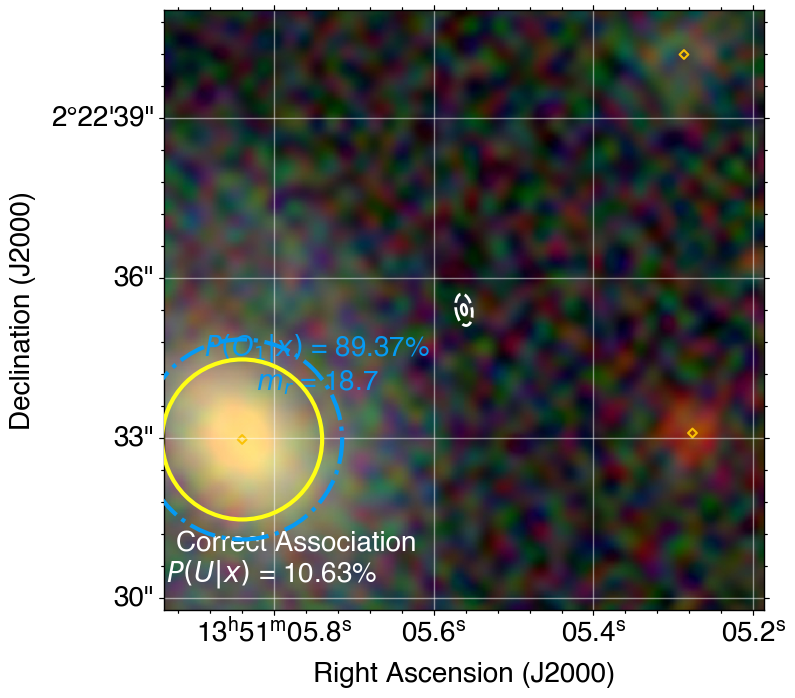

In [21]:
# Pick which survey to plot
survey_str = 'DECaL' # Can be: 'HSC', 'DECaL', 'Pan-STARRS'
size_arcmin = np.nanmax([2*angsize_host, 2*angsize_best_cand, 2*angsize_second_cand, 3.*a_err, 3.*b_err]) / 60. * 3

sup_fig = plt.figure(figsize=(6, 6))
axes = [0., 0., 1., 1.]

if POx_second_cand < 0.05:
    ra_second_cand, dec_second_cand, mag_second_cand, angsize_second_cand, POx_second_cand = None, None, None, None, None

sim_utils.plot_color_image(
    ra_true_host, dec_true_host,
    mag_true_host, angsize_host,
    ra_best_cand, dec_best_cand,
    mag_best_cand, angsize_best_cand,
    POx_best_cand, PUx,
    ra_loc, dec_loc,
    a_err, b_err, theta,
    sup_fig, axes, include_legend,
    size_arcmin=size_arcmin, filt="gri", 
    survey_str=survey_str, outfile=None, scale=99.9,
    all_cands=results,
    ra_second_cand=ra_second_cand, dec_second_cand=dec_second_cand,
    mag_second_cand=mag_second_cand, angsize_second_cand=angsize_second_cand,
    POx_second_cand=POx_second_cand, correct_association=digest_frb['correct_association'].item(),
)

In [14]:
angsize_best_cand

3.155649

In [11]:
size_arcmin = np.nanmax([3.*a_err, 3.*b_err]) * 60. * 100

In [12]:
size_arcmin*60/10

np.float64(3.000000000000001)

In [87]:
angsize_cand, angsize_host

(14.771363, 14.771363)

## Figure 11

Inverse Prior
True Positives: 3208
False Positives: 574
Negatives: 6218

Identical Prior
True Positives: 45
False Positives: 41
Negatives: 9914


/var/folders/yv/4m3blff94q33glq2zvkdpqd40000gn/T/ipykernel_96213/988937336.py:152: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xlabels)
/var/folders/yv/4m3blff94q33glq2zvkdpqd40000gn/T/ipykernel_96213/988937336.py:188: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xlabels)


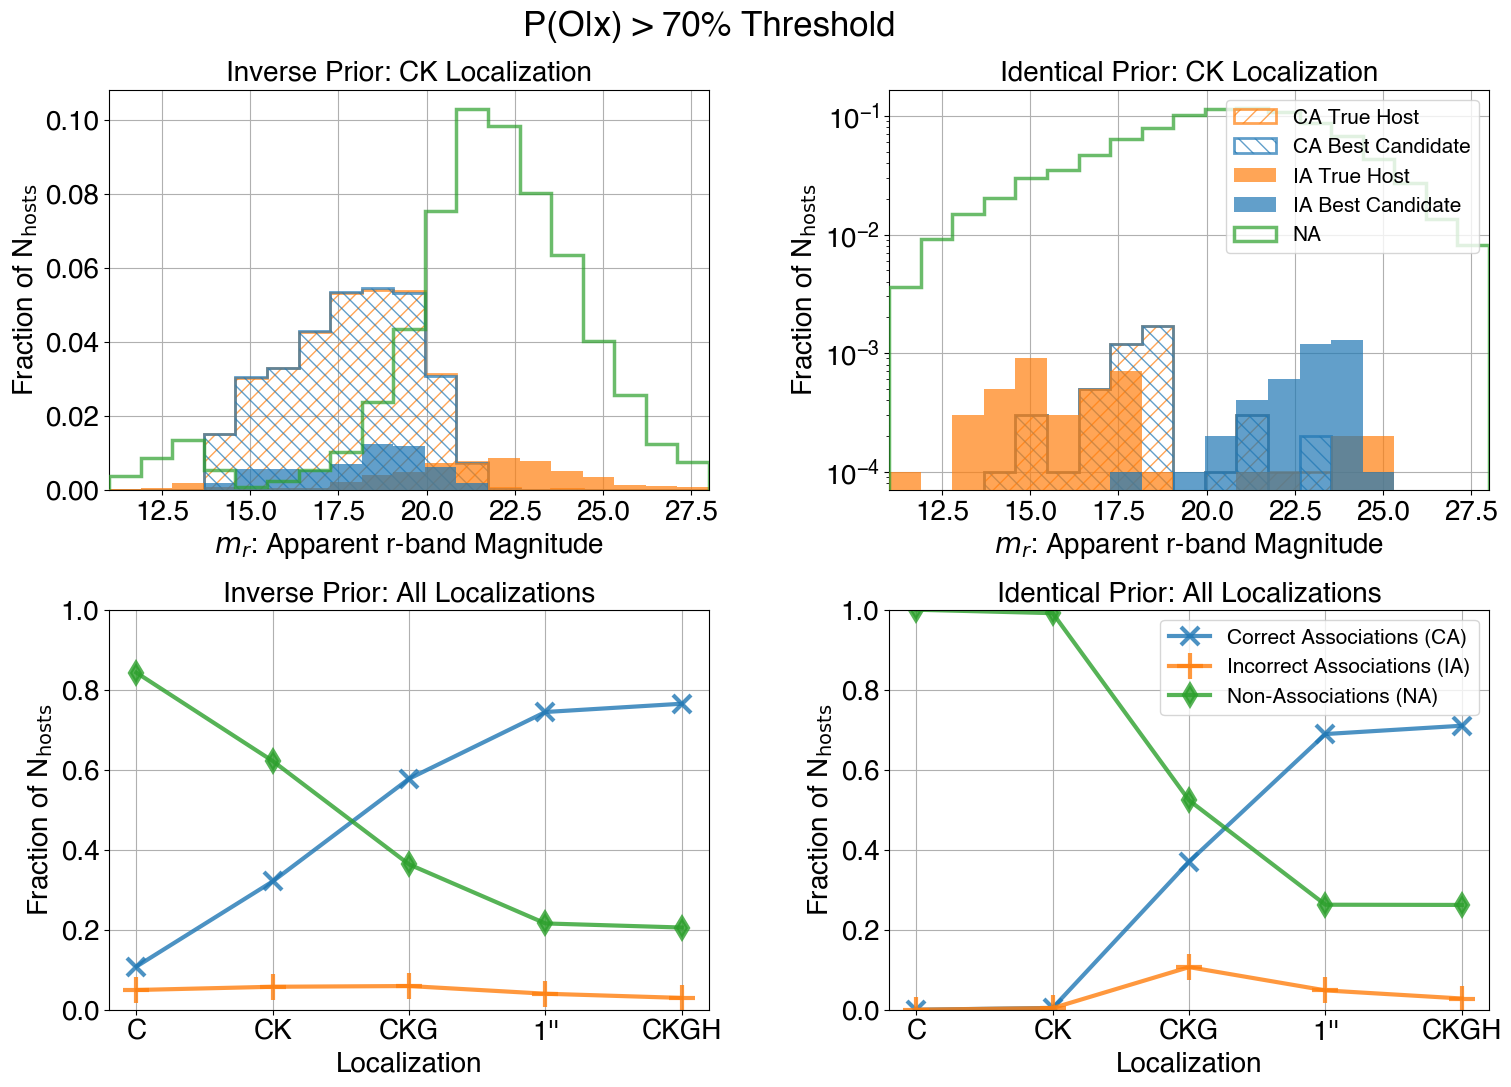

In [26]:
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = [cycle[0], cycle[1], cycle[2], cycle[4], 'black']
markers = ['x', '+', 'd', '*', 'o']
marker_sizes = [100, 150, 80, 100, 80]
linestyles = ['-', '--', '-.', (0, (3, 1, 1, 1, 1, 1)), (0, (1, 1))]

# (left, bottom, width, height)
width = 0.5
sep_w = 0.15
height = 0.5
sep_h = 0.15
inverse_hist_ax = (0., height+sep_h, width, height)
identical_hist_ax = (width+sep_w, height+sep_h, width, height)
inverse_fract_ax = (0., 0., width, height)
identical_fract_ax = (width+sep_w, 0., width, height)

fig = plt.figure(figsize=(12,8))
sim_name = 'CK'
loc = 'a25b2pa12'
P_Ox_thresh = 0.7
fig.suptitle('P(O|x) > {0:d}% Threshold'.format(int(P_Ox_thresh*100)), y=1.25, fontsize=25)
bins = np.linspace(11, 28, 20)

##################################################################################################
############################### Plotting Inverse Histogram #######################################
##################################################################################################

plotting_fn = os.path.join(os.getenv('FRB_APATH'), 'final_sims', f'digest_{loc}_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_final.parquet')
df = pd.read_parquet(plotting_fn)
Nfrbs = float(len(df))
print("Inverse Prior")

ax = plt.axes(inverse_hist_ax)

# Get true positives
df_selected = df[df['correct_association'] & (df['P_Ox'] > P_Ox_thresh)]
print("True Positives: {}".format(len(df_selected)))
mag_cands = df_selected['mag_cand']
mag_hosts = df_selected['mag_host']
P_Oxs = df_selected['P_Ox']
weights = np.ones_like(mag_hosts) / Nfrbs
_, _, _ = plt.hist(mag_hosts, density=False, weights=weights, facecolor='None', lw=2, edgecolor=cycle[1], alpha=0.7, bins=bins, zorder=5, hatch='//', fill='False', histtype='step', label='CA True Host')
plt.hist(mag_cands, density=False, weights=weights, facecolor='None', lw=2, edgecolor=cycle[0], alpha=0.7, bins=bins, zorder=5, hatch='\\\\', histtype='step', label='CA Best Candidate')

# Get false positives
df_selected = df[~df['correct_association'] & (df['P_Ox'] > P_Ox_thresh)]
print("False Positives: {}".format(len(df_selected)))
mag_cands = df_selected['mag_cand']
mag_hosts = df_selected['mag_host']
P_Oxs = df_selected['P_Ox']
weights = np.ones_like(mag_hosts) / Nfrbs
_, _, _ = plt.hist(mag_hosts, density=False, weights=weights,  color=cycle[1], alpha=0.7, bins=bins, zorder=5, label='IA True Host')
plt.hist(mag_cands, density=False, weights=weights,  color=cycle[0], alpha=0.7, bins=bins, zorder=5, label='IA Best Candidate')

# Get negatives
df_selected = df[df['P_Ox'] < P_Ox_thresh]
print("Negatives: {}".format(len(df_selected)))
mag_cands = df_selected['mag_cand']
mag_hosts = df_selected['mag_host']
P_Oxs = df_selected['P_Ox']
weights = np.ones_like(mag_hosts) / Nfrbs
_, bins, _ = plt.hist(mag_hosts, density=False, weights=weights, facecolor='None', lw=2.5, edgecolor=cycle[2], alpha=0.7, bins=bins, zorder=5, histtype='step', label='NA')

plt.title('Inverse Prior: CK Localization')
plt.xlabel('$m_r$: Apparent r-band Magnitude')
plt.ylabel(r'Fraction of N$_{\rm hosts}$')
handles, labels = ax.get_legend_handles_labels()
plt.grid(zorder=1)
plt.xlim([11,28])

print()
##################################################################################################
############################### Plotting Identical Histogram #####################################
##################################################################################################

plotting_fn = os.path.join(os.getenv('FRB_APATH'), 'final_sims', f'digest_{loc}_exponential_exp_identical_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_final.parquet')
df = pd.read_parquet(plotting_fn)
Nfrbs = float(len(df))
print("Identical Prior")

ax = plt.axes(identical_hist_ax)

# Get true positives
df_selected = df[df['correct_association'] & (df['P_Ox'] > P_Ox_thresh)]
print("True Positives: {}".format(len(df_selected)))
mag_cands = df_selected['mag_cand']
mag_hosts = df_selected['mag_host']
P_Oxs = df_selected['P_Ox']
weights = np.ones_like(mag_hosts) / Nfrbs
_, _, _ = plt.hist(mag_hosts, density=False, weights=weights, facecolor='None', lw=2, edgecolor=cycle[1], alpha=0.7, bins=bins, zorder=5, hatch='//', fill='False', histtype='step', label='CA True Host')
plt.hist(mag_cands, density=False, weights=weights, facecolor='None', lw=2, edgecolor=cycle[0], alpha=0.7, bins=bins, zorder=5, hatch='\\\\', histtype='step', label='CA Best Candidate')

# Get false positives
df_selected = df[~df['correct_association'] & (df['P_Ox'] > P_Ox_thresh)]
print("False Positives: {}".format(len(df_selected)))
mag_cands = df_selected['mag_cand']
mag_hosts = df_selected['mag_host']
mag_cands_fp = mag_cands
mag_hosts_fp = mag_hosts
P_Oxs = df_selected['P_Ox']
weights = np.ones_like(mag_hosts) / Nfrbs
_, _, _ = plt.hist(mag_hosts, density=False, weights=weights, color=cycle[1], alpha=0.7, bins=bins, zorder=5, label='IA True Host')
plt.hist(mag_cands, density=False, weights=weights, color=cycle[0], alpha=0.7, bins=bins, zorder=5, label='IA Best Candidate')

# Get negatives
df_selected = df[df['P_Ox'] < P_Ox_thresh]
print("Negatives: {}".format(len(df_selected)))
mag_cands = df_selected['mag_cand']
mag_hosts = df_selected['mag_host']
P_Oxs = df_selected['P_Ox']
weights = np.ones_like(mag_hosts) / Nfrbs
_, bins, _ = plt.hist(mag_hosts, density=False, weights=weights, facecolor='None', lw=2.5, edgecolor=cycle[2], alpha=0.7, bins=bins, zorder=5, histtype='step', label='NA')

plt.title('Identical Prior: CK Localization')
plt.xlabel('$m_r$: Apparent r-band Magnitude')
plt.ylabel(r'Fraction of N$_{\rm hosts}$')
plt.legend(handles, labels, fontsize=15, loc='upper right')
plt.grid(zorder=1)
plt.xlim([11,28])
# plt.ylim([0,0.005])
plt.yscale('log')

##################################################################################################
############################### Plotting Inverse Fractions #######################################
##################################################################################################
sim_names = ['a25b25pa0', 'a25b2pa12', 'a15b0pa5', 'a1b1pa0', 'a0b0pa10']
xlabels = ['', 'C', 'CK', 'CKG', "1''", 'CKGH', '']
TPs = []
FPs = []
Ns = []

ax = plt.axes(inverse_fract_ax)

for sim_name in sim_names:
    plotting_fn = os.path.join(os.getenv('FRB_APATH'), 'final_sims', f'digest_{sim_name}_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_final.parquet')
    df = pd.read_parquet(plotting_fn)
    Nfrbs = float(len(df))

    # True Positives
    df_selected = df[df['correct_association'] & (df['P_Ox'] > P_Ox_thresh)]
    TPs.append(len(df_selected)/Nfrbs)
    # False Positives
    df_selected = df[~df['correct_association'] & (df['P_Ox'] > P_Ox_thresh)]
    FPs.append(len(df_selected)/Nfrbs)
    # Negatives
    df_selected = df[df['P_Ox'] < P_Ox_thresh]
    Ns.append(len(df_selected)/Nfrbs)

plt.plot(np.arange(len(TPs)), TPs, color=cycle[0], lw=3, linestyle='solid', alpha=0.8, marker=markers[0], mew=3, markersize=marker_sizes[0]/8, label='True Positives')
plt.plot(np.arange(len(TPs)), FPs, color=cycle[1], lw=3, linestyle='solid', alpha=0.8, marker=markers[1], mew=3, markersize=marker_sizes[1]/8, label='False Positives')
plt.plot(np.arange(len(TPs)), Ns, color=cycle[2], lw=3, linestyle='solid', alpha=0.8, marker=markers[2], mew=3, markersize=marker_sizes[2]/8, label='Negatives')
ax.set_xticklabels(xlabels)
plt.title('Inverse Prior: All Localizations')
plt.xlabel('Localization')
plt.ylabel(r'Fraction of N$_{\rm hosts}$')
plt.grid(zorder=1)
plt.ylim([0,1.])

##################################################################################################
############################### Plotting Identical Fractions #####################################
##################################################################################################
sim_names = ['a25b25pa0', 'a25b2pa12', 'a15b0pa5', 'a1b1pa0', 'a0b0pa10']
xlabels = ['', 'C', 'CK', 'CKG', "1''", 'CKGH', '']
TPs = []
FPs = []
Ns = []

ax = plt.axes(identical_fract_ax)

run_name = 'identical'
for sim_name in sim_names:
    plotting_fn = os.path.join(os.getenv('FRB_APATH'), 'final_sims', f'digest_{sim_name}_exponential_exp_identical_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_final.parquet')
    df = pd.read_parquet(plotting_fn)

    # True Positives
    df_selected = df[df['correct_association'] & (df['P_Ox'] > P_Ox_thresh)]
    TPs.append(len(df_selected)/Nfrbs)
    # False Positives
    df_selected = df[~df['correct_association'] & (df['P_Ox'] > P_Ox_thresh)]
    FPs.append(len(df_selected)/Nfrbs)
    # Negatives
    df_selected = df[df['P_Ox'] < P_Ox_thresh]
    Ns.append(len(df_selected)/Nfrbs)

plt.plot(np.arange(len(TPs)), TPs, color=cycle[0], lw=3, linestyle='solid', alpha=0.8, marker=markers[0], mew=3, markersize=marker_sizes[0]/8, label='Correct Associations (CA)')
plt.plot(np.arange(len(TPs)), FPs, color=cycle[1], lw=3, linestyle='solid', alpha=0.8, marker=markers[1], mew=3, markersize=marker_sizes[1]/8, label='Incorrect Associations (IA)')
plt.plot(np.arange(len(TPs)), Ns, color=cycle[2], lw=3, linestyle='solid', alpha=0.8, marker=markers[2], mew=3, markersize=marker_sizes[2]/8, label='Non-Associations (NA)')
ax.set_xticklabels(xlabels)
plt.legend(fontsize=15)
plt.title('Identical Prior: All Localizations')
plt.xlabel('Localization')
plt.ylabel(r'Fraction of N$_{\rm hosts}$')
plt.grid(zorder=1)
plt.ylim([0,1.])

plot_fn = os.path.join(os.getenv('FRB_APATH'), 'paper_figures', 'inverse_vs_identical_mags_redo_norm_relabel.pdf')
plt.savefig(plot_fn, dpi=200, format="pdf", bbox_inches="tight")

## Figure 12

Plot the recovered distributions
Plot the false positives


/var/folders/yv/4m3blff94q33glq2zvkdpqd40000gn/T/ipykernel_7931/3331673882.py:120: RuntimeWarning: Mean of empty slice
  mag_bin_centers, np.nanmean(all_data, axis=0), yerr=np.nanstd(all_data, axis=0),
/Users/bandersen/miniforge3/envs/frbs2/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/yv/4m3blff94q33glq2zvkdpqd40000gn/T/ipykernel_7931/3331673882.py:120: RuntimeWarning: Mean of empty slice
  mag_bin_centers, np.nanmean(all_data, axis=0), yerr=np.nanstd(all_data, axis=0),
/Users/bandersen/miniforge3/envs/frbs2/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/yv/4m3blff94q33glq2zvkdpqd40000gn/T/ipykernel_7931/3331673882.py:120: RuntimeWarning: Mean of empty slice
  mag_bin_centers, np.nanmean(all_data,

Text(0.6, 1.15, '$\\rm P(O|x) > 90\\%$ Threshold')

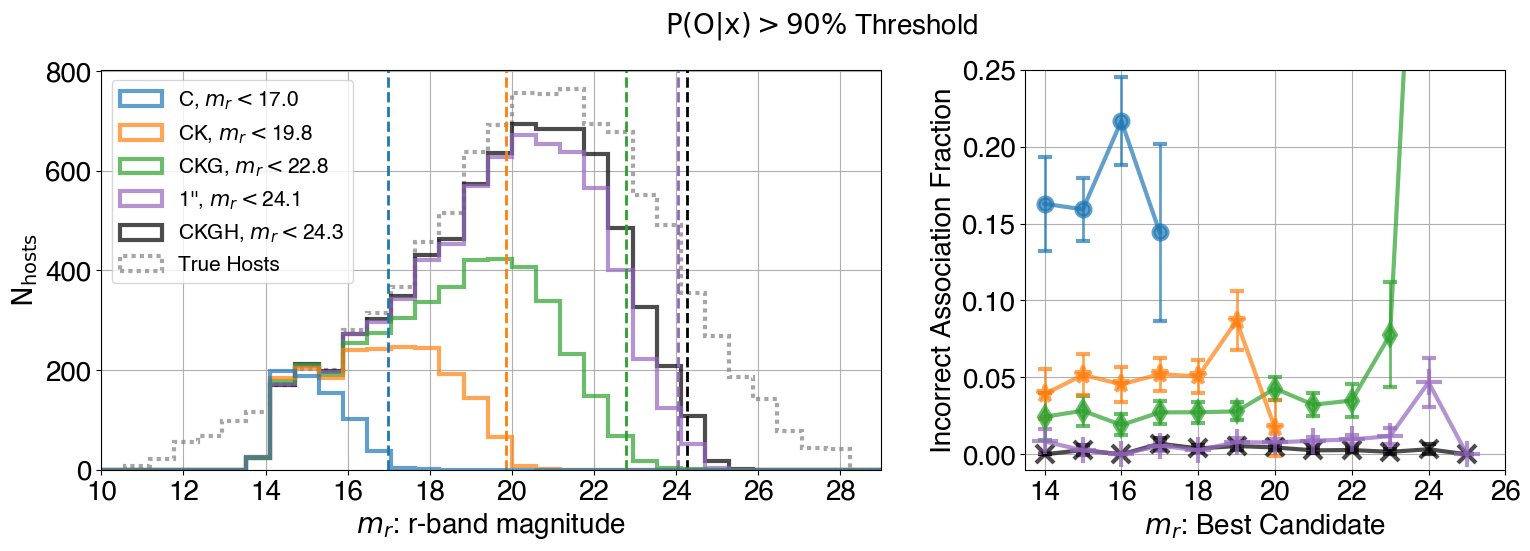

In [23]:
fig = plt.figure(figsize=(12, 4))
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = [cycle[0], cycle[1], cycle[2], cycle[4], 'black']
markers = ['x', '+', 'd', '*', 'o']
marker_sizes = [100, 150, 80, 100, 80]
linestyles = ['-', '--', '-.', (0, (3, 1, 1, 1, 1, 1)), (0, (1, 1))]

sim_names = ['a25b25pa0', 'a25b2pa12', 'a15b0pa5', 'a1b1pa0', 'a0b0pa10']
xlabels = ['C', 'CK', 'CKG', "1''", 'CKGH']
bins = np.linspace(10, 30, 35)
density = False
lw = 3

P_Ox_thresh = 0.9

# Reverse it all so baseband is visible
sim_names = sim_names[::-1]
xlabels = xlabels[::-1]
colors = colors[::-1]

# (left, bottom, width, height)
sep_w = 0.12
distr_ax = (0., 0., 0.65, 1.)
fp_ax = (0.65+sep_w, 0., 0.4, 1.)

ax = plt.axes(distr_ax)

print('Plot the recovered distributions')
# Plot the underlying simulated distribution
# plotting_fn = os.path.join(os.getenv('FRB_APATH'), 'final_sims', f'digest_a25b2pa12_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_final.parquet')
plotting_fn = os.path.join(os.getenv('FRB_APATH'), f'digest_a25b2pa12_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_discretize.parquet')
df = pd.read_parquet(plotting_fn)
mags_sim = df['mag_host']
_,_,_ = plt.hist(mags_sim, bins=bins, density=density, lw=lw, linestyle=(0, (1, 1)), edgecolor='grey', fill=False, histtype='step', alpha=0.7, label='True Hosts')
    
# Plot the recovered distributions
for ii, sim_name in enumerate(sim_names):
    plotting_fn = os.path.join(os.getenv('FRB_APATH'), 'final_sims', f'digest_{sim_name}_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_final.parquet')
    # plotting_fn = os.path.join(os.getenv('FRB_APATH'), f'digest_{sim_name}_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_discretize.parquet')
    df = pd.read_parquet(plotting_fn)
    mags_cand = df['mag_cand']
    mags_cand = mags_cand[df['P_Ox'] > P_Ox_thresh]
    
    # Find 95% limits
    lim_percent = 0.99
    n_tot = len(mags_cand)
    n = int(n_tot * lim_percent)
    for mag in np.linspace(10, 30, 1000):
        if len(mags_cand[mags_cand < mag]) > n:
            break
    
    label = "{0}, $m_r < ${1:.1f}".format(xlabels[ii], mag)
    _,_,_ = plt.hist(mags_cand, bins=bins, density=density, lw=lw, edgecolor=colors[ii], fill=False, histtype='step', alpha=0.7, label=label)
    plt.axvline(x=mag, lw=2, linestyle='dashed', color=colors[ii])
    
plt.xlabel('$m_r$: r-band magnitude')
plt.ylabel(r'$\rm N_{hosts}$')
plt.grid()
_ = plt.xticks(np.arange(10, 31, 2))
plt.xlim([10,29])
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[::-1], labels[::-1], fontsize=15, loc='upper left')
# plt.legend(fontsize=15, loc='upper left')

print('Plot the false positives')
ax = plt.axes(fp_ax)

# Plot the false-positive fractions
for jj, sim_name in enumerate(sim_names):
    plotting_fn = os.path.join(os.getenv('FRB_APATH'), 'final_sims', f'digest_{sim_name}_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_final.parquet')
    # plotting_fn = os.path.join(os.getenv('FRB_APATH'), f'digest_{sim_name}_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_discretize.parquet')
    df = pd.read_parquet(plotting_fn)
    
    # Jackknife to get errors
    N_boot = 200
    all_data = []
    for kk in range(N_boot):
        # Sample WITH replacement, keeping the total row count identical
        df_rs = df.sample(frac=1.0, replace=True)
#         # Remove 1/5 of points
#         inds = random.sample(range(len(df)), int(3*len(df)/5))
#         df_rs = df.iloc[inds]

        # Make a plot of the false positive rate (non-cumulative) vs best candidate magnitude
        # Split by P(O|x) cutoff (All, >80%, >90%, >95%)
        mag_bin_edges = np.arange(8.5, 28., 1.)
        fp_fraction = []
        for ii in range(len(mag_bin_edges)-1):
            mag_start_bin = mag_bin_edges[ii]
            mag_end_bin = mag_bin_edges[ii+1]
            fp_fraction.append([])
            df_selected = df_rs[(df_rs['P_Ox'] > P_Ox_thresh) & (df_rs['mag_cand'] > mag_start_bin) & (df_rs['mag_cand'] < mag_end_bin)]
            thresh = 2.
            max_ang_size = np.maximum.reduce([np.ones(len(df_selected))/thresh, df_selected['ang_size_cand'], df_selected['ang_size_host']], axis=0)
#             max_ang_size = (df_selected['ang_size_cand'] + df_selected['ang_size_host']).values
            match_criteria_fp = (df_selected['sep_best_host_arcsec'] < thresh*max_ang_size)
            df_selected_fp = df_selected[~match_criteria_fp]
#             df_selected_fp = df_selected[~df_selected['correct_association']]
            if len(df_selected) in range(10):
                fp_frac = np.nan
            else:
                fp_frac = len(df_selected_fp) / len(df_selected)
            fp_fraction[-1].append(fp_frac)
        fp_fraction = np.array(fp_fraction)
        mag_bin_centers = (mag_bin_edges[:-1] + mag_bin_edges[1:]) / 2.

        alpha = 0.8
        linestyle = 'solid'
        color = colors[jj]
        lw = 3
        ls = linestyles[jj]
        ms = markers[jj]
        s = marker_sizes[jj]
        zorder=5
        
        all_data.append(fp_fraction)
    all_data = np.array(all_data)[:,:,-1]
    
    plt.errorbar(
        mag_bin_centers, np.nanmean(all_data, axis=0), yerr=np.nanstd(all_data, axis=0), 
        capsize=5, elinewidth=2, markersize=s/8, mew=3, color=color, lw=3,
        marker=ms, alpha=0.7, label=label,# ls=ls
    ) 

plt.xlabel(r'$m_r$: Best Candidate')
plt.ylabel('Incorrect Association Fraction')
plt.grid(zorder=20)
plt.xlim([13.5,26.])
plt.ylim([-0.01, 0.25])
_ = plt.xticks(np.arange(14, 27, 2))
plt.suptitle(r'$\rm P(O|x) > 90\%$ Threshold', x=0.6, y=1.15, fontsize=20)

# plot_fn = os.path.join(os.getenv('CHIME_SANDBOX'), 'simulation_results', 'plots', 'paper_plot_data', 'mag_bias_overview_relabel2.pdf')
# plt.savefig(plot_fn, dpi=200, format="pdf", bbox_inches="tight")

In [34]:
# Print out number of correct, incorrect, and non-associations
sim_names = ['a25b25pa0', 'a25b2pa12', 'a15b0pa5', 'a1b1pa0', 'a0b0pa10']
P_Ox_thresh = 0.9
for ii, sim_name in enumerate(sim_names):
    plotting_fn = os.path.join(os.getenv('FRB_APATH'), 'final_sims', f'digest_{sim_name}_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_final.parquet')
    df = pd.read_parquet(plotting_fn)
    N = len(df)

    print("{0}, Overall Association Rate = {1:.2f}%".format(sim_name, len(df[df['P_Ox'] > P_Ox_thresh]) / N * 100.))
    print('CA: {0:.2f}%'.format(len(df[(df['P_Ox'] > P_Ox_thresh) & df['correct_association']]) / N * 100.))
    print('IA: {0:.2f}%'.format(len(df[(df['P_Ox'] > P_Ox_thresh) & ~df['correct_association']]) / N * 100.))
    print('NA: {0:.2f}%'.format(len(df[df['P_Ox'] < P_Ox_thresh])/ N * 100.))

a25b25pa0, Overall Association Rate = 7.06%
CA: 5.48%
IA: 1.58%
NA: 92.94%
a25b2pa12, Overall Association Rate = 19.80%
CA: 18.20%
IA: 1.60%
NA: 80.20%
a15b0pa5, Overall Association Rate = 41.96%
CA: 39.93%
IA: 2.03%
NA: 58.04%
a1b1pa0, Overall Association Rate = 69.11%
CA: 67.02%
IA: 2.09%
NA: 30.89%
a0b0pa10, Overall Association Rate = 74.69%
CA: 72.69%
IA: 2.00%
NA: 25.31%


In [37]:
# Print out number of correct, incorrect, and non-associations
sim_names = ['a25b25pa0', 'a25b2pa12', 'a15b0pa5', 'a1b1pa0', 'a0b0pa10']
P_Ox_thresh = 0.9
for ii, sim_name in enumerate(sim_names):
    plotting_fn = os.path.join(os.getenv('FRB_APATH'), f'digest_{sim_name}_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000.parquet')
    df = pd.read_parquet(plotting_fn)
    N = len(df)

    print("{0}, Overall Association Rate = {1:.2f}%".format(sim_name, len(df[df['P_Ox'] > P_Ox_thresh]) / N * 100.))
    print('CA: {0:.2f}%'.format(len(df[(df['P_Ox'] > P_Ox_thresh) & df['correct_association']]) / N * 100.))
    print('IA: {0:.2f}%'.format(len(df[(df['P_Ox'] > P_Ox_thresh) & ~df['correct_association']]) / N * 100.))
    print('NA: {0:.2f}%'.format(len(df[df['P_Ox'] < P_Ox_thresh])/ N * 100.))

a25b25pa0, Overall Association Rate = 7.15%
CA: 5.95%
IA: 1.20%
NA: 92.85%
a25b2pa12, Overall Association Rate = 20.94%
CA: 19.71%
IA: 1.23%
NA: 79.06%
a15b0pa5, Overall Association Rate = 45.78%
CA: 44.00%
IA: 1.78%
NA: 54.22%
a1b1pa0, Overall Association Rate = 71.38%
CA: 70.55%
IA: 0.83%
NA: 28.62%
a0b0pa10, Overall Association Rate = 75.58%
CA: 75.30%
IA: 0.28%
NA: 24.42%


In [41]:
# Print out number of correct, incorrect, and non-associations
sim_names = ['a25b25pa0', 'a25b2pa12', 'a15b0pa5', 'a1b1pa0', 'a0b0pa10']
P_Ox_thresh = 0.9
for ii, sim_name in enumerate(sim_names):
    plotting_fn = os.path.join(os.getenv('FRB_APATH'), f'digest_{sim_name}_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_origsim.parquet')
    df = pd.read_parquet(plotting_fn)
    N = len(df)

    print("{0}, Overall Association Rate = {1:.2f}%".format(sim_name, len(df[df['P_Ox'] > P_Ox_thresh]) / N * 100.))
    print('CA: {0:.2f}%'.format(len(df[(df['P_Ox'] > P_Ox_thresh) & df['correct_association']]) / N * 100.))
    print('IA: {0:.2f}%'.format(len(df[(df['P_Ox'] > P_Ox_thresh) & ~df['correct_association']]) / N * 100.))
    print('NA: {0:.2f}%'.format(len(df[df['P_Ox'] < P_Ox_thresh])/ N * 100.))

a25b2pa12, Overall Association Rate = 40.08%


KeyError: 'correct_association'

## Figure 13

## Figure 14

In [58]:
plotting_fn = os.path.join(os.getenv('FRB_APATH'), 'final_sims', f'digest_a25b2pa12_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_final.parquet')
df = pd.read_parquet(plotting_fn)

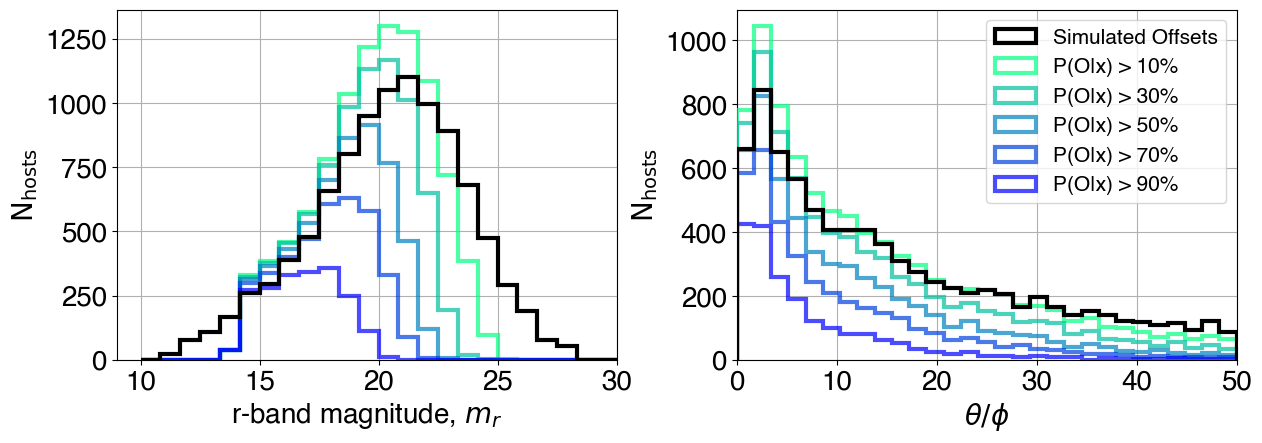

In [59]:
# Plot true FRB offsets from host center
fig = plt.figure(figsize=(10,3.5))
lw=3
P_Ox_list = [0.1, 0.3, 0.5, 0.7, 0.9] 
colors = plt.cm.winter(np.linspace(0,1,len(P_Ox_list)))[::-1]
bins = np.linspace(10, 30, 25)
density = False

# (left, bottom, width, height)
width = 0.5
sep_w = 0.12
mag_ax = (0., 0., width, 1.)
offset_ax = (width+sep_w, 0., width, 1.)

# Plot the true simulated offset distribution
ax = plt.axes(mag_ax)
mags_host = df['mag_host'].values
n_tot,bins,_ = plt.hist(mags_host, bins=bins, density=density, lw=lw, linestyle='solid', edgecolor='black', fill=False, histtype='step', alpha=1., label='Simulated Magnitudes', zorder=40) # hatch='||',
# Plot the recovered offset distribution for confident associations
for ii, P_Ox in enumerate(P_Ox_list):
    mask = (df['P_Ox'] > P_Ox)
    n_tot,bins,_ = plt.hist(df['mag_cand'][mask], bins=bins, density=density, lw=lw, linestyle='solid', edgecolor=colors[ii], fill=False, histtype='step', alpha=0.7, label='P(O|x) > {}%'.format(int(P_Ox*100)), zorder=30) # hatch='||',
plt.xlabel(r'r-band magnitude, $m_r$')
plt.ylabel(r'$\rm N_{hosts}$')
plt.xlim([9,30])
plt.grid()

ax = plt.axes(offset_ax)
# Set bins and x-axis zoom
theta_max = int(2*np.nanmax([df['a'],df['b']]))
theta_max = np.nanmax([theta_max, 6])
bins = np.linspace(0, theta_max, 30) # 35
# Calculate true host offsets
coord_host = SkyCoord(ra=df['ra_host'], dec=df['dec_host'], unit='deg')
coord_loc = SkyCoord(ra=df['ra_loc'], dec=df['dec_loc'], unit='deg')
sep_host_loc = coord_host.separation(coord_loc).arcsec
# Calculate best candidate offsets
coord_best = SkyCoord(ra=df['ra_cand'], dec=df['dec_cand'], unit='deg')
coord_loc = SkyCoord(ra=df['ra_loc'], dec=df['dec_loc'], unit='deg')
sep_best_loc = coord_best.separation(coord_loc).arcsec
# Calculate offsets
sim_offsets_norm = sep_host_loc/df['ang_size_host'].values
offsets_norm = sep_best_loc/df['ang_size_cand'].values
# Plot the true simulated offset distribution
n_tot,bins,_ = plt.hist(sim_offsets_norm, bins=bins, density=density, lw=lw, edgecolor='black', linestyle='solid', fill=False, histtype='step', alpha=1., label='Simulated Offsets', zorder=40) # hatch='||',
# Plot the recovered offset distribution for confident associations
for ii, P_Ox in enumerate(P_Ox_list):
    mask = (df['P_Ox'] > P_Ox)
    _,bins,_ = plt.hist(offsets_norm[mask], bins=bins, density=density, lw=lw, linestyle='solid', histtype='step', color=colors[ii], alpha=0.7, label='P(O|x) > {}%'.format(int(P_Ox*100)), zorder=30) # hatch='//', 
plt.xlabel(r'$\theta/\phi$')
plt.ylabel(r'$\rm N_{hosts}$')
plt.legend(fontsize=15)
plt.xlim([0,theta_max])
plt.grid(zorder=20)

# plot_fn = os.path.join(os.getenv('CHIME_SANDBOX'), 'paper_plot_data', 'mag_offset_varypox_norm.pdf')
# plt.savefig(plot_fn, dpi=200, format="pdf", bbox_inches="tight")

In [61]:
df.keys()

Index(['ra_loc', 'dec_loc', 'true_ra', 'true_dec', 'host_ID', 'gal_off',
       'mag_host', 'ang_size_host', 'loc_off', 'FRB_ID', 'a', 'b', 'PA',
       'ra_host', 'dec_host', 'sep_best_host_arcsec', 'sep_host_loc_arcsec',
       'sep_host_loc_norm', 'sep_best_loc_arcsec', 'sep_best_loc_norm',
       'z_host', 'dmex_host', 'frb_mr', 'frb_Mr', 'ra_cand', 'dec_cand',
       'ang_size_cand', 'mag_cand', 'cand_ID', 'P_O', 'P_Ox', 'P_Ux',
       'correct_association', 'unseen', 'host_catalog'],
      dtype='str')

## Figure 15

a25b25pa0
a25b2pa12
a15b0pa5
a1b1pa0
a0b0pa10
a25b25pa0
a25b2pa12
a15b0pa5
a1b1pa0
a0b0pa10


(-0.01, 1.01)

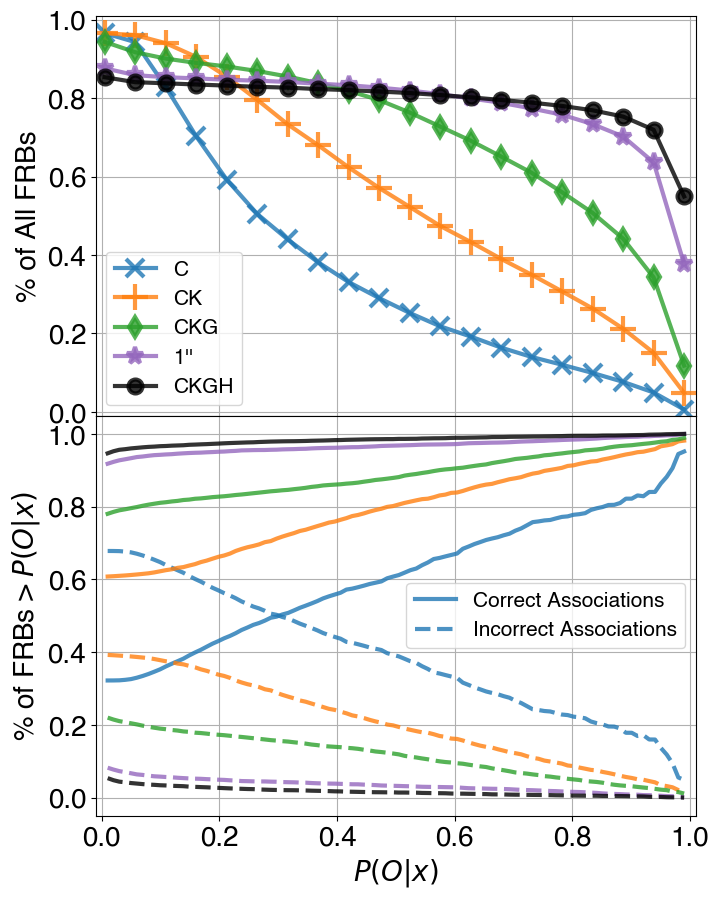

In [72]:
# What percentage of *ALL* FRBs will be above P(O|x)?
sim_names = ['a25b25pa0', 'a25b2pa12', 'a15b0pa5', 'a1b1pa0', 'a0b0pa10']
locs = [
    (25., 25., 0.), # Baseband
    (15., 2., 12.), # KKO
    (15., 50./1000., 5.), # GBO
    (100./1000., 50./1000., 80.), # HCO
]
survey_str = 'DECaL'

cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = [cycle[0], cycle[1], cycle[2], cycle[4], 'black']
markers = ['x', '+', 'd', '*', 'o']
marker_sizes = [100, 150, 80, 100, 80]
linestyles = ['-', '--', '-.', (0, (3, 1, 1, 1, 1, 1)), (0, (1, 1))]

fig = plt.figure(figsize=(6,8))

# (left, bottom, width, height)
sep_w = 0.1
assoc_rate_ax = (0, 0.5, 1., 0.5)
TPFP_ax = (0., 0., 1., 0.5)

###########################################################################################
############################### Plot Association Rates ####################################
###########################################################################################

save = []
ax = plt.axes(assoc_rate_ax)
for jj in range(len(sim_names)):
    sim_name = sim_names[jj]
    print(sim_name)
    
    plotting_fn = os.path.join(os.getenv('FRB_APATH'), 'final_sims', f'digest_{sim_name}_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_final.parquet')
    df = pd.read_parquet(plotting_fn)
#     df = df[df['mag_host'] > 15]
    
    # Plot fraction of true positive (TP) vs false positive (FP)
    # as a function of P(O|x) cut
    P_Ox_thresh = np.linspace(0.005, 0.99, 20)#0.99, 1000)
    F_above = []
    F_below = []
    for P_Ox in P_Ox_thresh:
        df_above = df[(df['P_Ox'] > P_Ox) & (df['mag_host'] > 14)]
        df_below = df[(df['P_Ox'] < P_Ox) & (df['mag_host'] > 14)]
        f_above = len(df_above) / len(df)
        f_below = len(df_below) / len(df)
        F_above.append(f_above)
        F_below.append(f_below)
    F_above = np.array(F_above)
    F_below = np.array(F_below)
    
    if sim_name == 'a25b2pa12':
        save = F_above
    
    if sim_name == 'a25b25pa0':
        label = 'C'
    elif sim_name == 'a25b2pa12':
        label = "CK"
    elif sim_name == 'a15b0pa5':
        label = "CKG"
    elif sim_name == 'a0b0pa10':
        label = "CKGH"
    elif sim_name == 'a1b1pa0':
        label = "1''"
    else:
        label = f"{sim_name.upper()}"
    alpha = 0.8
    label = label
    linestyle = 'solid'
    color = colors[jj]
    lw = 3
    ls = linestyles[jj]
    ms = markers[jj]
    s = marker_sizes[jj]
    zorder=5
    
    plt.plot(
        P_Ox_thresh, F_above, color=colors[jj], 
        ms=s/8, label=label, alpha=0.8, 
        lw=3, marker=ms, mew=3, # ls=ls, 
    )
    #plt.scatter(P_Ox_thresh, F_below, marker='x', color=color, s=50, label='{} Fraction < P(O|x)'.format(label))
    
plt.ylabel(r'% of All FRBs')
plt.xlabel(r'$P(O|x)$')
plt.legend(fontsize=15)#, bbox_to_anchor=(1., 0.8))
plt.grid()
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
ax.set_xticklabels([])
# plt.axvline(x=0.9, color='black')

###########################################################################################
################################## Plot TP/FP Rates #######################################
###########################################################################################

ax = plt.axes(TPFP_ax)
for jj in range(len(sim_names)):
    sim_name = sim_names[jj]
#     loc = locs[jj]
    print(sim_name)
    
    plotting_fn = os.path.join(os.getenv('FRB_APATH'), 'final_sims', f'digest_{sim_name}_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_final.parquet')
    df = pd.read_parquet(plotting_fn)
#     df = df[df['mag_host'] > 15]
    
#     max_ang_size = np.maximum.reduce([df['ang_size_cand'], df['half_light_host']], axis=0)
#     match_criteria = (df['sep_best_host'] > 1.5*max_ang_size)
    
    # Plot fraction of true positive (TP) vs false positive (FP)
    # as a function of P(O|x) cut
    P_Ox_thresh = np.linspace(0.01, 0.99, 100)
    TPs = []
    FPs = []
    for P_Ox in P_Ox_thresh:
        df_selected = df[df['P_Ox'] > P_Ox]
    #     df_selected_fp = df_selected[(df_selected['host_ID'] != df_selected['cand_ID']) & (df_selected['mag_cand'] > 17.)]
    #     df_selected_tp = df_selected[(df_selected['host_ID'] == df_selected['cand_ID']) & (df_selected['mag_cand'] > 17.)]
        max_ang_size = np.maximum.reduce([df_selected['ang_size_cand'], df_selected['ang_size_host']], axis=0)
        match_criteria_tp = (df_selected['sep_best_host_arcsec'] < 2.*max_ang_size)
        df_selected_fp = df_selected[~match_criteria_tp]
        df_selected_tp = df_selected[match_criteria_tp]
        fp_frac = len(df_selected_fp) / len(df_selected)
        tp_frac = len(df_selected_tp) / len(df_selected)
#         if sim_name == 'baseband':
#             print(P_Ox, len(df_selected), tp_frac)
        TPs.append(tp_frac)
        FPs.append(fp_frac)
    FPs = np.array(FPs)
    TPs = np.array(TPs)
    
    # Plot fraction of true positive (TP) vs false positive (FP)
    # as a function of P(O|x) cut
    TNs = []
    FNs = []
    for P_Ox in P_Ox_thresh:
        df_selected = df[df['P_Ox'] < P_Ox]
    #     df_selected_fp = df_selected[(df_selected['host_ID'] != df_selected['cand_ID']) & (df_selected['mag_cand'] > 17.)]
    #     df_selected_tp = df_selected[(df_selected['host_ID'] == df_selected['cand_ID']) & (df_selected['mag_cand'] > 17.)]
        max_ang_size = np.maximum.reduce([df_selected['ang_size_cand'], df_selected['ang_size_host']], axis=0)
        match_criteria_fp = (df_selected['sep_best_host_arcsec'] > 2.*max_ang_size)
        df_selected_fp = df_selected[match_criteria_fp]
        df_selected_tp = df_selected[~match_criteria_fp]
        if (len(df_selected) > 0):
            fp_frac = len(df_selected_fp) / len(df_selected)
            tp_frac = len(df_selected_tp) / len(df_selected)
        else: 
            fp_frac = np.nan
            tp_frac = np.nan
        TNs.append(tp_frac)
        FNs.append(fp_frac)
    FNs = np.array(FNs)
    TNs = np.array(TNs)

    if sim_name == 'a25b25pa0':
        label = 'C'
    elif sim_name == 'a25b2pa12':
        label = "CK"
    elif sim_name == 'a15b0pa5':
        label = "CKG"
    elif sim_name == 'a0b0pa10':
        label = "CKGH"
    elif sim_name == 'a1b1pa0':
        label = "1''"
    else:
        label = f"{sim_name.upper()}"
    alpha = 0.8
    linestyle = 'solid'
    color = colors[jj]
    lw = 3
    ls = linestyles[jj]
    ms = markers[jj]
    s = marker_sizes[jj]
    zorder=5
    
    if sim_name == 'a25b25pa0':
        label1='Correct Associations'.format(label)
        label2='Incorrect Associations'.format(label) 
    else:
        label1=None
        label2=None
    plt.plot(
        P_Ox_thresh, TPs, color=colors[jj], 
        ms=s/8, alpha=0.8, label=label1,
        lw=3, marker='None', mew=3,
    )
    plt.plot(
        P_Ox_thresh, FPs, color=colors[jj], 
        ms=s/8, alpha=0.8, label=label2,
        lw=3, marker='None', mew=3, ls='dashed',
    )
    
    
#     plt.scatter(P_Ox_thresh, TPs, marker='o', color=color, s=50, label='{} TP'.format(label))
#     plt.scatter(P_Ox_thresh, FPs, marker='x', color=color, s=50, label='{} FP'.format(label))
    
plt.ylabel(r'% of FRBs > $P(O|x)$')
plt.xlabel(r'$P(O|x)$')
plt.legend(fontsize=15)#, bbox_to_anchor=(1.0, 0.86))
plt.grid()
plt.xlim([-0.01, 1.01])

# plot_fn = os.path.join(os.getenv('CHIME_SANDBOX'), 'paper_plot_data', 'assoc_rates_redo_relabel2.pdf')
# plt.savefig(plot_fn, dpi=200, format="pdf", bbox_inches="tight")

## Figure 16

In [70]:
plotting_fn = os.path.join(os.getenv('FRB_APATH'), 'final_sims', f'digest_a25b2pa12_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_final.parquet')
df = pd.read_parquet(plotting_fn)

In [71]:
fn = os.path.join(os.getenv('FRB_APATH'), 'final_sims', f'full_path_results_{loc}_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_final.parquet')
df_results = pd.read_parquet(fn)

In [81]:
# Get the localization ra, dec for each iFRB
# Get the host ra, dec for each iFRB
ra_locs = []
dec_locs = []
ra_hosts = []
dec_hosts = []
half_light_hosts = []
mag_hosts = []
for ii, host in df.iterrows():
    if ii % 500 == 0:
        print(ii)
    iFRB = host['FRB_ID']
    cands = df_results[df_results['iFRB'] == iFRB]
    N = len(cands)
    ra_locs = ra_locs + [host['ra_loc']]*N
    dec_locs = dec_locs + [host['dec_loc']]*N
    ra_hosts = ra_hosts + [host['ra_host']]*N
    dec_hosts = dec_hosts + [host['dec_host']]*N
    half_light_hosts = half_light_hosts + [host['ang_size_host']]*N
    mag_hosts = mag_hosts + [host['mag_host']]*N
    # ra_locs.append(host['ra_loc'].values[0])
    # dec_locs.append(host['dec_loc'].values[0])
    # ra_hosts.append(host['ra_host'].values[0])
    # dec_hosts.append(host['dec_host'].values[0])
    # half_light_hosts.append(host['half_light_host'].values[0])
ra_locs = np.array(ra_locs)
dec_locs = np.array(dec_locs)
ra_hosts = np.array(ra_hosts)
dec_hosts = np.array(dec_hosts)
half_light_hosts = np.array(half_light_hosts)
mag_hosts = np.array(mag_hosts)

0
500
1000
1500
2000
2500
3000
3500


KeyboardInterrupt: 

In [ ]:
# Add to results dataframe
df_results['ra_loc'] = ra_locs
df_results['dec_loc'] = dec_locs
df_results['ra_host'] = ra_hosts
df_results['dec_host'] = dec_hosts
df_results['half_light_host'] = half_light_hosts
df_results['mag_host'] = mag_hosts

In [ ]:
# We have the separation between the best candidate and the localization
# Now calculate the separation between the true host and the localization
coord_best = SkyCoord(ra=df_results['ra'], dec=df_results['dec'], unit='deg')
coord_loc = SkyCoord(ra=df_results['ra_loc'], dec=df_results['dec_loc'], unit='deg')
sep_best_loc = coord_best.separation(coord_loc).arcsec

In [ ]:
# We have the separation between the best candidate and the localization
# Now calculate the separation between the true host and the localization
coord_host = SkyCoord(ra=df_results['ra_host'], dec=df_results['dec_host'], unit='deg')
coord_loc = SkyCoord(ra=df_results['ra_loc'], dec=df_results['dec_loc'], unit='deg')
sep_host_loc = coord_host.separation(coord_loc).arcsec

In [ ]:
df_results['sep_host_loc'] = sep_host_loc
df_results['sep_best_loc'] = sep_best_loc

In [ ]:
df_results.to_parquet(os.path.join(os.getenv('FRB_APATH'), 'final_sims', f'full_path_results_{loc}_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_final_fullinfo.parquet')

In [ ]:
import numpy as np
from astropy.coordinates import SkyCoord

plotting_fn = os.path.join(os.getenv('FRB_APATH'), 'final_sims', f'digest_a25b2pa12_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_final.parquet')
fn = os.path.join(os.getenv('FRB_APATH'), 'final_sims', f'full_path_results_a25b2pa12_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_final.parquet')

print('Only pull the columns we need from the (small) host digest')
host = pd.read_parquet(
    plotting_fn,
    columns=['FRB_ID', 'ra_loc', 'dec_loc', 'ra_host', 'dec_host', 'ang_size_host', 'mag_host'],
).set_index('FRB_ID')

df_results = pd.read_parquet(fn)
key = df_results['iFRB']

print('Build as plain ndarrays so `host` and the aligned Series can be freed immediately')
cols = {
    'ra_loc':          key.map(host['ra_loc']).to_numpy(),
    'dec_loc':         key.map(host['dec_loc']).to_numpy(),
    'ra_host':         key.map(host['ra_host']).to_numpy(),
    'dec_host':        key.map(host['dec_host']).to_numpy(),
    'half_light_host': key.map(host['ang_size_host']).to_numpy(),
    'mag_host':        key.map(host['mag_host']).to_numpy(),
}
del host, key
for name, arr in cols.items():
    df_results[name] = arr
del cols

print('Build coord_loc ONCE, reuse it, and free each partner coord right after use')
coord_loc = SkyCoord(ra=df_results['ra_loc'].to_numpy(), dec=df_results['dec_loc'].to_numpy(), unit='deg')

coord_best = SkyCoord(ra=df_results['ra'].to_numpy(), dec=df_results['dec'].to_numpy(), unit='deg')
df_results['sep_best_loc'] = coord_best.separation(coord_loc).arcsec
del coord_best

coord_host = SkyCoord(ra=df_results['ra_host'].to_numpy(), dec=df_results['dec_host'].to_numpy(), unit='deg')
df_results['sep_host_loc'] = coord_host.separation(coord_loc).arcsec
del coord_host, coord_loc

df_results.to_parquet(out_fn)

Only pull the columns we need from the (small) host digest
Build as plain ndarrays so `host` and the aligned Series can be freed immediately
Build coord_loc ONCE, reuse it, and free each partner coord right after use


In [74]:
offsets_norm = df_results['sep_best_loc']/df_results['ang_size'].values # sep_best_loc

# Now let's calculate the CDF of the distribution
# Sort by offset
args_sort = offsets_norm.argsort()
offsets_norm_sorted = offsets_norm.iloc[args_sort]
P_Ox_sorted = df_results.iloc[args_sort].P_Ox
# P_Ox_sorted = df_results.P_Ox[args_sort]
# Cumulatively sum
cdf = np.cumsum(P_Ox_sorted.values) #* offsets_norm_sorted.values
cdf_off = cdf / cdf[-1]

# Sample from the cdf
x = np.linspace(0, 10, len(cdf))
cdf_y_samples = np.random.uniform(cdf_off[0], cdf_off[-1], size=len(df))
cdf_x_samples_off = np.interp(cdf_y_samples, cdf_off, offsets_norm_sorted) # apply inverse CDF

KeyError: 'sep_best_loc_arcsec'

In [ ]:
# Now let's calculate the CDF of the distribution
# Sort by magnitude
mags = df_results['mag'].values
args_sort = mags.argsort()
mags_sorted = mags[args_sort]
P_Ox_sorted = df_results.iloc[args_sort].P_Ox
# Cumulatively sum
cdf = np.cumsum(P_Ox_sorted.values) #* offsets_norm_sorted.values
cdf_mag = cdf / cdf[-1]

# Sample from the cdf
cdf_y_samples = np.random.uniform(cdf_mag[0], cdf_mag[-1], size=int(1e5))
cdf_x_samples_mag = np.interp(cdf_y_samples, cdf_mag, mags_sorted) # apply inverse CDF

NameError: name 'cdf_x_samples_mag' is not defined

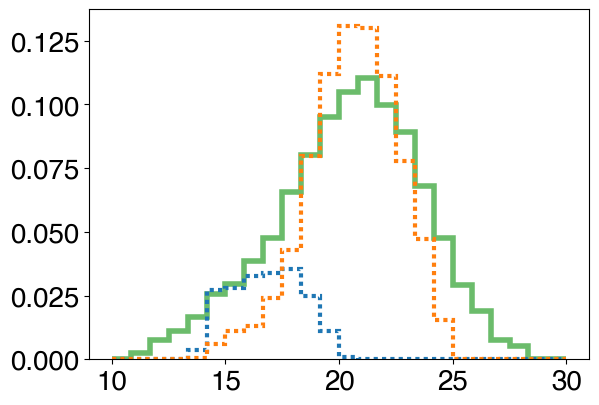

In [69]:
# Plot true FRB offsets from host center
fig = plt.figure(figsize=(10,3.5))
lw=4
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
bins = np.linspace(10, 30, 25)
density = True

# (left, bottom, width, height)
width = 0.5
sep_w = 0.12
mag_ax = (0., 0., width, 1.)
offset_ax = (width+sep_w, 0., width, 1.)

# Plot the true simulated offset distribution
ax = plt.axes(mag_ax)
mags_host = df['mag_host'].values
weights = np.ones_like(mags_host) / float(len(mags_host))
n_tot,bins,_ = plt.hist(mags_host, bins=bins, weights=weights, density=False, lw=lw, edgecolor=cycle[2], fill=False, histtype='step', alpha=0.7, label='Simulated Magnitudes') # hatch='||',
# Plot the recovered offset distribution for confident associations
mask = (df['P_Ox'] > 0.9)
weights = np.ones_like(df['mag_cand'][mask]) / float(len(mags_host))
_,_,_ = plt.hist(df['mag_cand'][mask], bins=bins, weights=weights, density=False, lw=3, edgecolor=cycle[0], linestyle=(0, (1, 1)), fill=False, histtype='step', alpha=1., label='P(O|x) > 90%') # hatch='||',
# arr_hist, edges = np.histogram(df['mag_cand'][mask], bins=bins)
# samp = arr_hist / (df['mag_cand'][mask].shape[0] * np.diff(edges))
# plt.step(bins[1:], samp/np.nanmax(samp)*np.nanmax(n_tot), lw=3, linestyle=(0, (1, 1)), color=cycle[0], alpha=1., label='P(O|x) > 90%', zorder=30)
# Plot the recovered offset distribution for confident associations
mask = (df['P_Ox'] < 0.9) 
weights = np.ones_like(df['mag_cand'][mask]) / float(len(mags_host))
_,_,_ = plt.hist(df['mag_cand'][mask], bins=bins, weights=weights, density=False, lw=3, edgecolor=cycle[1], linestyle=(0, (1, 1)), fill=False, histtype='step', alpha=1., label='P(O|x) < 90%') # hatch='||',
# arr_hist, edges = np.histogram(df['mag_cand'][mask], bins=bins)
# samp = arr_hist / (df['mag_cand'][mask].shape[0] * np.diff(edges))
# plt.step(bins[1:], samp/np.nanmax(samp)*np.nanmax(n_tot), lw=3, linestyle=(0, (1, 1)), color=cycle[1], alpha=1., label='P(O|x) < 90%', zorder=30)
# Plot recovered PDF
# inds = random.sample(range(len(cdf_x_samples_mag)), len(df))
# inds = random.sample(range(len(cdf_x_samples_mag)), len(df))
# weights = np.ones_like(cdf_x_samples_mag[inds]) / float(len(cdf_x_samples_mag[inds]))
# n,bins,_ = plt.hist(cdf_x_samples_mag[inds], bins=bins, density=density, lw=lw, histtype='step', color='#AA4499', alpha=0.7, label='"Corrected" by CDF') # hatch='\\\\',
arr_hist, edges = np.histogram(cdf_x_samples_mag, bins=bins)
samp = arr_hist / (cdf_x_samples_mag.shape[0] * np.diff(edges))
plt.step(bins[1:], samp/np.nanmax(samp)*np.nanmax(n_tot), lw=lw, color='#AA4499', alpha=0.7, label='"Corrected" Distribution')

plt.xlabel(r'r-band magnitude, $m_r$')
plt.ylabel(r'$P(m_r)$')
# plt.legend(bbox_to_anchor=(1.55, 0.9),loc='upper right',fontsize=15)
# plt.title(f'DECaLs, KKO')
plt.xlim([9,30])
plt.grid()

ax = plt.axes(offset_ax)
# Set bins and x-axis zoom
theta_max = int(2*np.nanmax([df['a'],df['b']]))
theta_max = np.nanmax([theta_max, 6])
bins = np.linspace(0, theta_max, 30) # 35
# Calculate true host offsets
coord_host = SkyCoord(ra=df['ra_host'], dec=df['dec_host'], unit='deg')
coord_loc = SkyCoord(ra=df['ra_loc'], dec=df['dec_loc'], unit='deg')
sep_host_loc = coord_host.separation(coord_loc).arcsec
# Calculate best candidate offsets
coord_best = SkyCoord(ra=df['ra_cand'], dec=df['dec_cand'], unit='deg')
coord_loc = SkyCoord(ra=df['ra_loc'], dec=df['dec_loc'], unit='deg')
sep_best_loc = coord_best.separation(coord_loc).arcsec
# Calculate offsets
sim_offsets_norm = sep_host_loc/df['ang_size_host'].values
offsets_norm = sep_best_loc/df['ang_size_cand'].values
# Plot the true simulated offset distribution
weights = np.ones_like(sim_offsets_norm) / float(len(sim_offsets_norm))
n_tot, bins,_ = plt.hist(sim_offsets_norm, bins=bins, density=False, weights=weights, lw=lw, edgecolor=cycle[2], fill=False, histtype='step', alpha=0.7, label='Simulated Offsets') # hatch='||',
# Plot the recovered offset distribution for confident associations
mask = (df['P_Ox'] > 0.9)
weights = np.ones_like(offsets_norm[mask]) / float(len(sim_offsets_norm))
_,bins,_ = plt.hist(offsets_norm[mask], bins=bins, weights=weights, density=False, lw=3, linestyle=(0, (1, 1)), histtype='step', color=cycle[0], alpha=1., label='P(O|x) > 90%', zorder=30) # hatch='//', 
# # Plot the recovered offset distribution for confident associations
mask = (df['P_Ox'] < 0.9)
weights = np.ones_like(offsets_norm[mask]) / float(len(sim_offsets_norm))
_,bins,_ = plt.hist(offsets_norm[mask], bins=bins, weights=weights, density=False, lw=3, linestyle=(0, (1, 1)), histtype='step', color=cycle[1], alpha=1., label='P(O|x) < 90%', zorder=30) # hatch='\\\\',
# Calculate prior
phi = 1. # Angular size of the galaxy in arcseconds
thetas = np.linspace(0,100,4000) # offset from galaxy center in arcsec
dtheta = thetas[1] - thetas[0]
theta_prior = dict(PDF='exp', max=6., scale=0.5)
ptheta = pw_Oi(thetas, phi, theta_prior)
# Convolve with localization
more_thetas, convolved_ptheta = convolve_with_loc(df, thetas, ptheta)
# # Plot the prior
# more_thetas = np.arange(convolved_ptheta.size) * dtheta
# plt.plot(more_thetas, convolved_ptheta / np.nanmax(convolved_ptheta) * np.nanmax(n_tot), lw=3, color='xkcd:black', label='Exponential Prior')
# Plot recovered PDF
# inds = random.sample(range(len(cdf_x_samples_off)), len(df))
# n,bins,_ = plt.hist(cdf_x_samples_off[inds], bins=bins, density=True, lw=lw, histtype='step', color='#AA4499', alpha=0.7, label='"Corrected" by CDF') # hatch='\\\\',
# inds = random.sample(range(len(cdf_x_samples_off)), len(df))
# weights = np.ones_like(cdf_x_samples_off[inds]) / float(len(cdf_x_samples_off[inds]))
# n,bins,_ = plt.hist(cdf_x_samples_off[inds], bins=bins, density=density, lw=lw, histtype='step', color='#AA4499', alpha=0.7, label='"Corrected" by CDF') # hatch='\\\\',
arr_hist, edges = np.histogram(cdf_x_samples_off, bins=bins)
samp = arr_hist / (cdf_x_samples_off.shape[0] * np.diff(edges))
plt.step(bins[1:], samp/np.nanmax(samp)*np.nanmax(n_tot), lw=lw, color='#AA4499', alpha=0.7, label='"Corrected" Distribution')

plt.xlabel(r'$\theta/\phi$')
plt.ylabel(r'$P(\theta/\phi)$')
plt.legend(fontsize=15)
plt.xlim([0,theta_max])
plt.grid(zorder=20)

# plot_fn = os.path.join(os.getenv('CHIME_SANDBOX'), 'paper_plot_data', 'mag_offset_nocorrections_wprior.pdf')
# plt.savefig(plot_fn, dpi=200, format="pdf", bbox_inches="tight")